# SNFAC Observations vs Sarvalanche Detected Tracks

Compares SNFAC avalanche observations (point data) against sarvalanche-detected tracks (polygons) from high-danger dates:
1. **Spatial analysis** — how many observations intersect, are near, or are far from detected tracks
2. **Temporal analysis** — how many spatially-nearby observations also match a sarvalanche run date
3. **Observation attributes** — wet vs dry, d-size, type, trigger, problem type for matched vs unmatched
4. **Example observations** — specific cases at different distance bins and multi-track intersections for visual QC
5. **Per-zone and per-date breakdown** — detection rates by zone and avalanche date
6. **Unmatched observations** — what types of avalanches are we missing?

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
import ast
import re
from pathlib import Path
from shapely.geometry import Point, box
from shapely.ops import unary_union

BASE_DIR = Path('/Users/zmhoppinen/Documents/sarvalanche/local/issw/high_danger_output')
OBS_CSV = BASE_DIR / 'snfac_obs_2021_2025.csv'
RUNS_DIR = BASE_DIR / 'sarvalanche_runs'

ZONE_SHORT = {
    'Banner Summit': 'Banner',
    'Galena Summit & Eastern Mtns': 'Galena',
    'Sawtooth & Western Smoky Mtns': 'Sawtooth',
    'Soldier & Wood River Valley Mtns': 'Soldier',
    'Challis/Lost River/Lemhi': 'Challis',
}

# Bins for pd.cut (5 edges -> 4 labels); "Intersects" handled separately for dist==0
DIST_BINS = [0, 100, 250, 500, 1000, np.inf]
DIST_CUT_LABELS = ['0-100m', '100-250m', '250-500m', '500m-1km', '>1km']
ALL_DIST_LABELS = ['Intersects (0m)'] + DIST_CUT_LABELS

# Avalanche type decode
AVAL_TYPE = {'HS': 'Hard Slab', 'SS': 'Soft Slab', 'WL': 'Wet Loose', 'WS': 'Wet Slab',
             'L': 'Loose', 'C': 'Cornice', 'R': 'Roof', 'U': 'Unknown'}

# Trigger decode
TRIGGER = {'N': 'Natural', 'AS': 'Skier', 'AM': 'Snowmobiler', 'AE': 'Explosive',
           'AV': 'Vehicle', 'AF': 'Foot', 'AC': 'Cornice fall', 'AO': 'Other human',
           'AW': 'Wildlife', 'NC': 'Cornice collapse', 'NO': 'Other natural', 'U': 'Unknown'}

# Wet vs dry classification from avalanche_problem
WET_PROBLEMS = {'Wet Slab', 'Wet Loose', 'Glide'}
DRY_PROBLEMS = {'Persistent Slab', 'Deep Persistent Slab', 'Wind Slab', 'Dry Loose', 'Storm Slab'}

## 1. Load data

In [2]:
# --- Observations ---
obs_raw = pd.read_csv(OBS_CSV)

def parse_point(loc_str):
    try:
        d = ast.literal_eval(loc_str)
        return Point(d['lng'], d['lat'])
    except Exception:
        return None

obs_raw['geometry'] = obs_raw['location_point'].apply(parse_point)
obs = gpd.GeoDataFrame(
    obs_raw.dropna(subset=['geometry']), geometry='geometry', crs='EPSG:4326'
).to_crs('EPSG:32611')
obs['obs_date'] = pd.to_datetime(obs['date'])
obs['zone_short'] = obs['zone_name'].map(ZONE_SHORT).fillna(obs['zone_name'])

# Derived attributes
obs['type_label'] = obs['avalanche_type'].map(AVAL_TYPE).fillna('Unknown')
obs['trigger_label'] = obs['trigger'].map(TRIGGER).fillna('Unknown')
obs['d_size_num'] = pd.to_numeric(obs['d_size'], errors='coerce')
obs['r_size_num'] = pd.to_numeric(obs['r_size'], errors='coerce')
obs['elevation_ft'] = pd.to_numeric(obs['elevation'], errors='coerce')
obs['crown_depth_cm'] = pd.to_numeric(obs['avg_crown_depth'], errors='coerce')
obs['width_m'] = pd.to_numeric(obs['width'], errors='coerce')
obs['vert_fall_ft'] = pd.to_numeric(obs['vertical_fall'], errors='coerce')

# Wet vs dry
def classify_moisture(row):
    prob = row.get('avalanche_problem')
    atype = row.get('avalanche_type')
    if isinstance(prob, str):
        if prob in WET_PROBLEMS:
            return 'Wet'
        if prob in DRY_PROBLEMS:
            return 'Dry'
    if isinstance(atype, str):
        if atype in ('WL', 'WS'):
            return 'Wet'
        if atype in ('SS', 'HS', 'L'):
            return 'Dry'
    return 'Unknown'

obs['moisture'] = obs.apply(classify_moisture, axis=1)

print(f'Observations loaded: {len(obs)} (dropped {len(obs_raw) - len(obs)} without geometry)')
print(f'Date range: {obs["obs_date"].min().date()} to {obs["obs_date"].max().date()}')
print(f'Zones: {sorted(obs["zone_short"].unique())}')
print(f'\nMoisture: {obs["moisture"].value_counts().to_dict()}')
print(f'Avalanche types: {obs["type_label"].value_counts().to_dict()}')

Observations loaded: 1386 (dropped 0 without geometry)
Date range: 2021-12-12 to 2025-04-08
Zones: ['Banner', 'Challis', 'Galena', 'Sawtooth', 'Soldier']

Moisture: {'Unknown': 838, 'Dry': 444, 'Wet': 104}
Avalanche types: {'Unknown': 988, 'Soft Slab': 212, 'Hard Slab': 101, 'Wet Slab': 42, 'Wet Loose': 38, 'Cornice': 3, 'Roof': 1, 'Loose': 1}


In [3]:
# --- Tracks (geopackages) ---
gpkg_paths = sorted(RUNS_DIR.glob('*.gpkg'))
all_tracks_list = []
for p in gpkg_paths:
    gdf = gpd.read_file(p)
    zone = p.stem.rsplit('_', 1)[0].replace('_', ' ').replace('&', '&')
    gdf['zone'] = zone
    all_tracks_list.append(gdf)
    print(f'  {zone}: {len(gdf)} tracks')

all_tracks = pd.concat(all_tracks_list, ignore_index=True)
print(f'\nTotal tracks: {len(all_tracks)}')

  Banner Summit: 644 tracks
  Galena Summit & Eastern Mtns: 4570 tracks
  Sawtooth & Western Smoky Mtns: 3625 tracks
  Soldier & Wood River Valley Mtns: 3052 tracks

Total tracks: 11891


In [4]:
# --- Avalanche run dates from netCDF filenames ---
nc_files = sorted(RUNS_DIR.glob('*.nc'))
run_dates = []
for f in nc_files:
    m = re.match(r'(.+)_(\d{4}-\d{2}-\d{2})\.nc$', f.name)
    if m:
        zone = m.group(1).replace('_', ' ').replace('&', '&')
        run_dates.append({'zone': zone, 'run_date': pd.to_datetime(m.group(2))})
run_dates_df = pd.DataFrame(run_dates)
unique_run_dates = sorted(run_dates_df['run_date'].unique())

print(f'Sarvalanche run dates ({len(unique_run_dates)}):')
for d in unique_run_dates:
    zones = run_dates_df[run_dates_df['run_date'] == d]['zone'].tolist()
    print(f'  {pd.Timestamp(d).date()}: {len(zones)} zones')

Sarvalanche run dates (8):
  2022-12-12: 4 zones
  2023-03-13: 4 zones
  2023-04-01: 4 zones
  2024-01-12: 4 zones
  2024-02-05: 4 zones
  2024-02-29: 4 zones
  2024-12-29: 4 zones
  2025-02-04: 4 zones


## 2. Spatial analysis — distance to nearest track

In [5]:
# Distance from each observation to nearest track
tracks_union = unary_union(all_tracks.geometry)
obs['dist_to_track'] = obs.geometry.distance(tracks_union)

# Assign distance bins: "Intersects" for dist==0, pd.cut for the rest
nonzero = obs['dist_to_track'] > 0
cut_result = pd.cut(
    obs.loc[nonzero, 'dist_to_track'], bins=DIST_BINS, labels=DIST_CUT_LABELS,
    right=True, include_lowest=False,
).astype(str)
obs['dist_bin'] = 'Intersects (0m)'
obs.loc[nonzero, 'dist_bin'] = cut_result

# Count tracks intersected per observation (spatial join)
joined = gpd.sjoin(obs[['geometry']], all_tracks[['geometry']], how='inner', predicate='intersects')
track_counts = joined.groupby(joined.index).size().rename('n_tracks_intersected')
obs['n_tracks_intersected'] = track_counts.reindex(obs.index).fillna(0).astype(int)

# Convenience flags
obs['matched_500m'] = obs['dist_to_track'] <= 500
obs['matched_250m'] = obs['dist_to_track'] <= 250
obs['intersects_track'] = obs['n_tracks_intersected'] > 0

print('Distance to nearest track:')
dist_summary = obs['dist_bin'].value_counts().reindex(ALL_DIST_LABELS)
for label, count in dist_summary.items():
    print(f'  {label:20s}: {count:4d}  ({100*count/len(obs):.1f}%)')

print(f'\nDistance statistics (m): mean={obs["dist_to_track"].mean():.0f}, '
      f'median={obs["dist_to_track"].median():.0f}, '
      f'P90={obs["dist_to_track"].quantile(0.9):.0f}, '
      f'max={obs["dist_to_track"].max():.0f}')

Distance to nearest track:
  Intersects (0m)     :  521  (37.6%)
  0-100m              :  338  (24.4%)
  100-250m            :  176  (12.7%)
  250-500m            :  145  (10.5%)
  500m-1km            :  125  (9.0%)
  >1km                :   81  (5.8%)

Distance statistics (m): mean=221, median=36, P90=667, max=3507


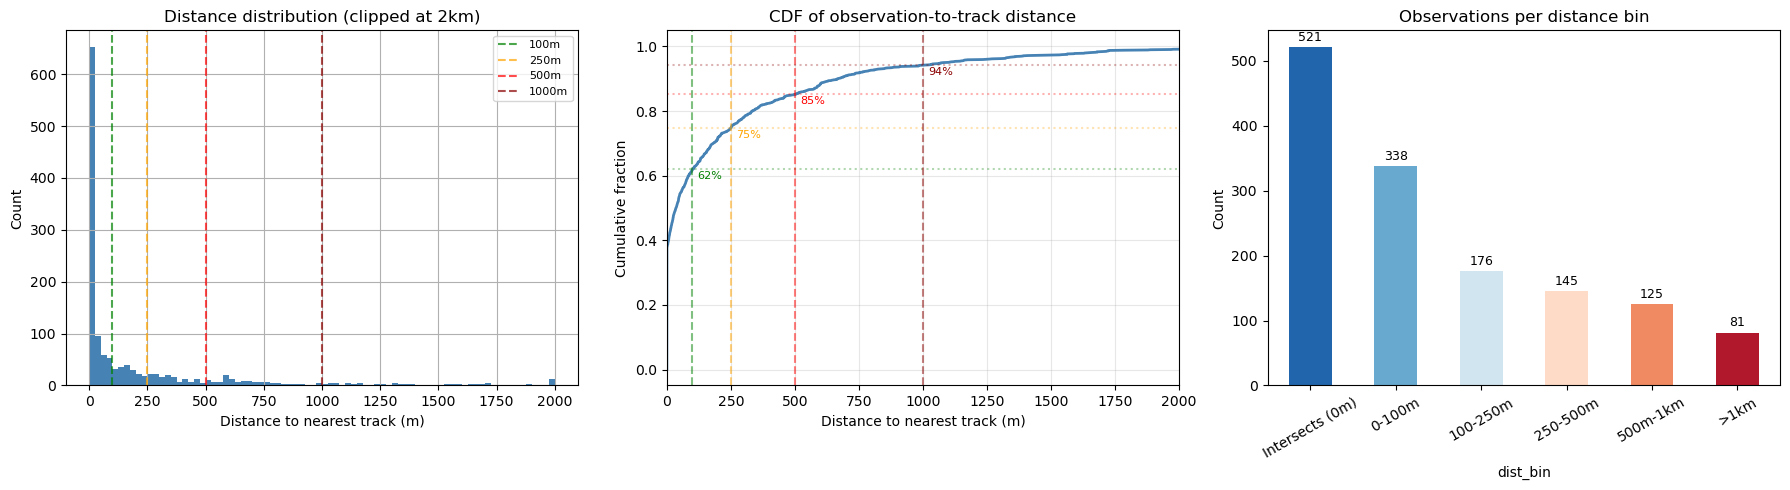

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Histogram of distances ---
ax = axes[0]
obs['dist_to_track'].clip(upper=2000).hist(bins=80, ax=ax, color='steelblue', edgecolor='none')
for thresh, color in [(100, 'green'), (250, 'orange'), (500, 'red'), (1000, 'darkred')]:
    ax.axvline(thresh, color=color, linestyle='--', alpha=0.7, label=f'{thresh}m')
ax.set_xlabel('Distance to nearest track (m)')
ax.set_ylabel('Count')
ax.set_title('Distance distribution (clipped at 2km)')
ax.legend(fontsize=8)

# --- Cumulative distribution ---
ax = axes[1]
sorted_dists = np.sort(obs['dist_to_track'].values)
cdf = np.arange(1, len(sorted_dists) + 1) / len(sorted_dists)
ax.plot(sorted_dists, cdf, color='steelblue', linewidth=2)
ax.set_xlim(0, 2000)
for thresh, color in [(100, 'green'), (250, 'orange'), (500, 'red'), (1000, 'darkred')]:
    frac = (sorted_dists <= thresh).sum() / len(sorted_dists)
    ax.axvline(thresh, color=color, linestyle='--', alpha=0.5)
    ax.axhline(frac, color=color, linestyle=':', alpha=0.3)
    ax.text(thresh + 20, frac - 0.03, f'{frac:.0%}', fontsize=8, color=color)
ax.set_xlabel('Distance to nearest track (m)')
ax.set_ylabel('Cumulative fraction')
ax.set_title('CDF of observation-to-track distance')
ax.grid(True, alpha=0.3)

# --- Bar chart of distance bins ---
ax = axes[2]
colors_bar = ['#2166ac', '#67a9cf', '#d1e5f0', '#fddbc7', '#ef8a62', '#b2182b']
dist_summary.plot.bar(ax=ax, color=colors_bar)
ax.set_ylabel('Count')
ax.set_title('Observations per distance bin')
ax.tick_params(axis='x', rotation=30)
for i, (label, val) in enumerate(dist_summary.items()):
    ax.text(i, val + 10, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
# --- Multi-track intersections ---
intersecting = obs[obs['n_tracks_intersected'] > 0]
multi = obs[obs['n_tracks_intersected'] > 1]

print(f'Observations intersecting >= 1 track: {len(intersecting)}')
print(f'Observations intersecting >  1 track: {len(multi)} ({100*len(multi)/len(obs):.1f}% of all obs)')
print(f'\nTrack intersection counts (among those that intersect):')
print(intersecting['n_tracks_intersected'].value_counts().sort_index().to_string())

Observations intersecting >= 1 track: 521
Observations intersecting >  1 track: 221 (15.9% of all obs)

Track intersection counts (among those that intersect):
n_tracks_intersected
1    300
2    180
3     28
4      4
5      3
6      3
7      2
8      1


## 3. Spatial analysis by zone

Observations per distance bin by zone:
dist_bin    Intersects (0m)  0-100m  100-250m  250-500m  500m-1km  >1km  total  <=500m %
zone_short                                                                              
Banner                   21      15         7         4         3     5     55      85.5
Challis                   1       1         1         1         0     0      4     100.0
Galena                  300     155        71        69        59    36    690      86.2
Sawtooth                166     131        53        15         5     5    375      97.3
Soldier                  33      36        44        56        58    35    262      64.5


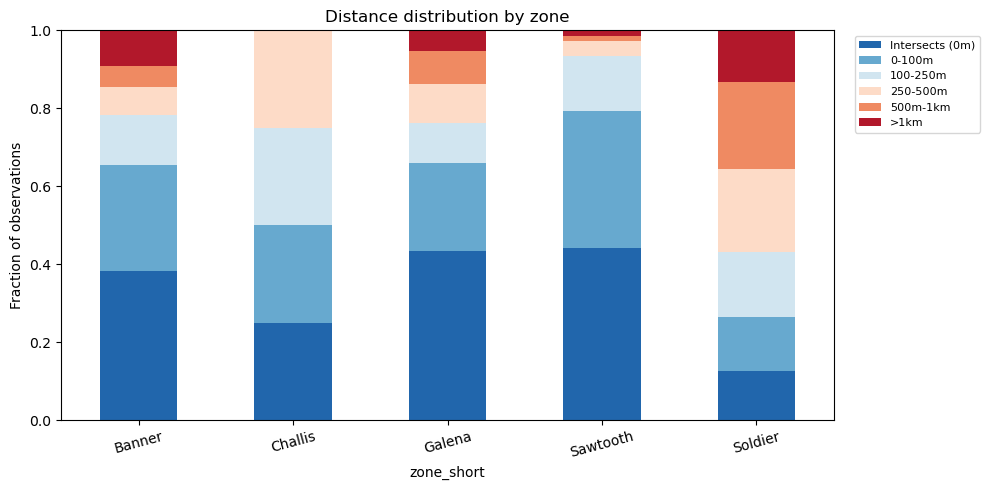

In [8]:
# Distance bins by zone
zone_dist = pd.crosstab(obs['zone_short'], obs['dist_bin'])
zone_dist = zone_dist.reindex(columns=ALL_DIST_LABELS, fill_value=0)
zone_dist['total'] = zone_dist.sum(axis=1)
zone_dist['<=500m %'] = (zone_dist[ALL_DIST_LABELS[:4]].sum(axis=1) / zone_dist['total'] * 100).round(1)

print('Observations per distance bin by zone:')
print(zone_dist.to_string())

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))
zone_frac = zone_dist[ALL_DIST_LABELS].div(zone_dist['total'], axis=0)
zone_frac.plot.bar(stacked=True, ax=ax, color=colors_bar)
ax.set_ylabel('Fraction of observations')
ax.set_title('Distance distribution by zone')
ax.tick_params(axis='x', rotation=15)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Temporal analysis

In [9]:
# For each observation, find the minimum days to any sarvalanche run date
all_run_dates_arr = np.array([np.datetime64(d) for d in unique_run_dates])

def min_days_to_dates(obs_date, dates_arr):
    if pd.isna(obs_date):
        return np.inf
    diffs = np.abs((np.datetime64(obs_date) - dates_arr) / np.timedelta64(1, 'D'))
    return float(diffs.min())

obs['min_days_any'] = obs['obs_date'].apply(lambda d: min_days_to_dates(d, all_run_dates_arr))

# Zone-matched
zone_date_lookup = run_dates_df.groupby('zone')['run_date'].apply(
    lambda s: np.array([np.datetime64(d) for d in s])
).to_dict()

def min_days_zone_matched(row):
    zone = row['zone_name']
    dates = zone_date_lookup.get(zone)
    if dates is None or len(dates) == 0:
        return np.inf
    return min_days_to_dates(row['obs_date'], dates)

obs['min_days_zone'] = obs.apply(min_days_zone_matched, axis=1)

# Filter to observations within 500m
nearby = obs[obs['dist_to_track'] <= 500].copy()
print(f'Observations within 500m of a track: {len(nearby)}')

print(f'\nTemporal proximity (zone-agnostic):')
for window in [3, 6, 12, 18]:
    n = (nearby['min_days_any'] <= window).sum()
    print(f'  +-{window:2d} days: {n:4d} / {len(nearby)}  ({100*n/len(nearby):.1f}%)')

print(f'\nTemporal proximity (zone-matched):')
for window in [3, 6, 12, 18]:
    n = (nearby['min_days_zone'] <= window).sum()
    print(f'  +-{window:2d} days: {n:4d} / {len(nearby)}  ({100*n/len(nearby):.1f}%)')

Observations within 500m of a track: 1180

Temporal proximity (zone-agnostic):
  +- 3 days:  542 / 1180  (45.9%)
  +- 6 days:  647 / 1180  (54.8%)
  +-12 days:  827 / 1180  (70.1%)
  +-18 days:  903 / 1180  (76.5%)

Temporal proximity (zone-matched):
  +- 3 days:  538 / 1180  (45.6%)
  +- 6 days:  643 / 1180  (54.5%)
  +-12 days:  823 / 1180  (69.7%)
  +-18 days:  899 / 1180  (76.2%)


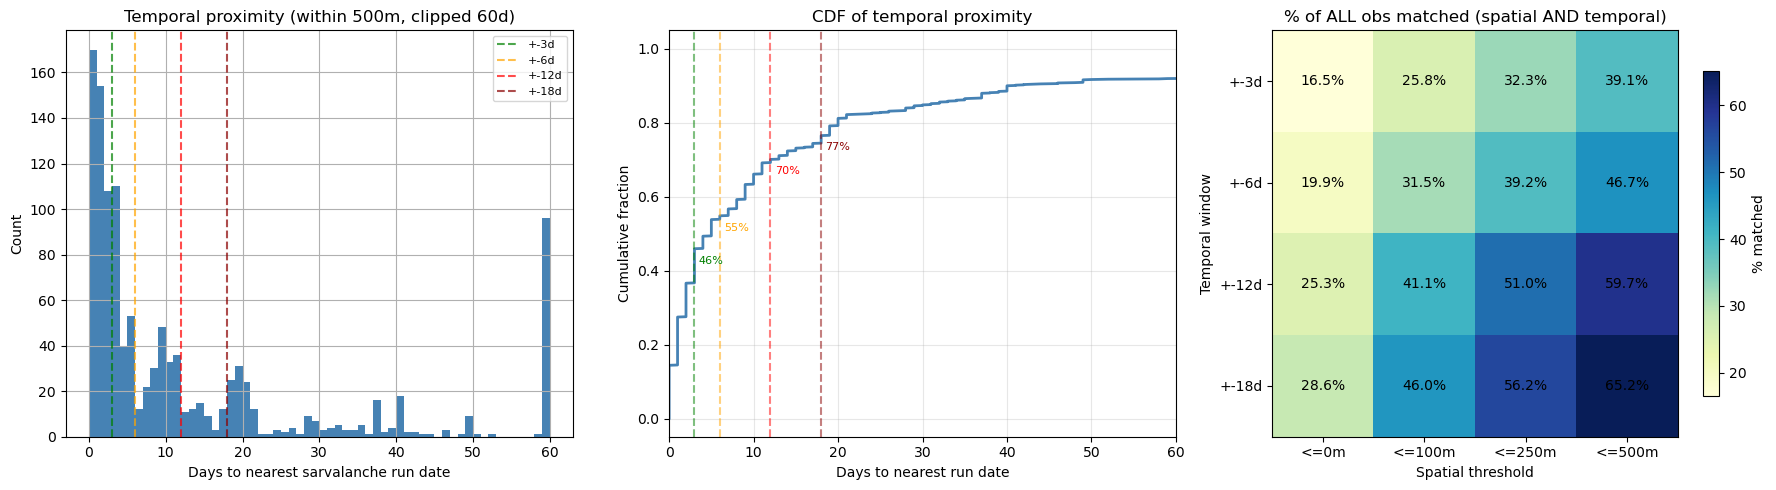

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Histogram of days to nearest run date ---
ax = axes[0]
nearby['min_days_any'].clip(upper=60).hist(bins=60, ax=ax, color='steelblue', edgecolor='none')
for thresh, color in [(3, 'green'), (6, 'orange'), (12, 'red'), (18, 'darkred')]:
    ax.axvline(thresh, color=color, linestyle='--', alpha=0.7, label=f'+-{thresh}d')
ax.set_xlabel('Days to nearest sarvalanche run date')
ax.set_ylabel('Count')
ax.set_title('Temporal proximity (within 500m, clipped 60d)')
ax.legend(fontsize=8)

# --- CDF ---
ax = axes[1]
sorted_days = np.sort(nearby['min_days_any'].values)
cdf = np.arange(1, len(sorted_days) + 1) / len(sorted_days)
ax.plot(sorted_days, cdf, color='steelblue', linewidth=2)
ax.set_xlim(0, 60)
for thresh, color in [(3, 'green'), (6, 'orange'), (12, 'red'), (18, 'darkred')]:
    frac = (sorted_days <= thresh).sum() / len(sorted_days)
    ax.axvline(thresh, color=color, linestyle='--', alpha=0.5)
    ax.text(thresh + 0.5, frac - 0.04, f'{frac:.0%}', fontsize=8, color=color)
ax.set_xlabel('Days to nearest run date')
ax.set_ylabel('Cumulative fraction')
ax.set_title('CDF of temporal proximity')
ax.grid(True, alpha=0.3)

# --- Combined spatial + temporal summary ---
ax = axes[2]
time_windows = [3, 6, 12, 18]
dist_thresholds = [0, 100, 250, 500]
grid = np.zeros((len(time_windows), len(dist_thresholds)))
for i, tw in enumerate(time_windows):
    for j, dt in enumerate(dist_thresholds):
        n = ((obs['dist_to_track'] <= dt) & (obs['min_days_any'] <= tw)).sum()
        grid[i, j] = 100 * n / len(obs)

im = ax.imshow(grid, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(dist_thresholds)))
ax.set_xticklabels([f'<={d}m' for d in dist_thresholds])
ax.set_yticks(range(len(time_windows)))
ax.set_yticklabels([f'+-{w}d' for w in time_windows])
ax.set_xlabel('Spatial threshold')
ax.set_ylabel('Temporal window')
ax.set_title('% of ALL obs matched (spatial AND temporal)')
for i in range(len(time_windows)):
    for j in range(len(dist_thresholds)):
        ax.text(j, i, f'{grid[i,j]:.1f}%', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label='% matched', shrink=0.8)

plt.tight_layout()
plt.show()

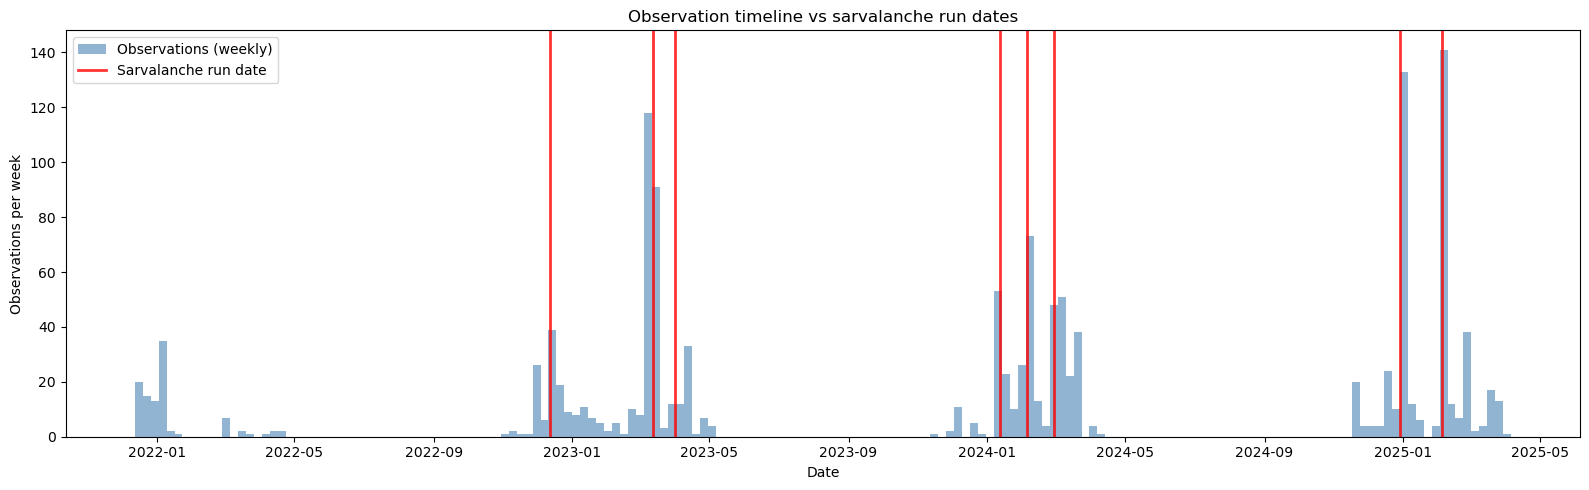

In [11]:
# Timeline: observation dates vs sarvalanche run dates
fig, ax = plt.subplots(figsize=(16, 5))

obs_dates = obs['obs_date'].dropna()
date_range = pd.date_range(obs_dates.min(), obs_dates.max(), freq='W')
ax.hist(obs_dates, bins=date_range, color='steelblue', alpha=0.6, label='Observations (weekly)')

for i, d in enumerate(unique_run_dates):
    ax.axvline(pd.Timestamp(d), color='red', linewidth=2, alpha=0.8,
               label='Sarvalanche run date' if i == 0 else None)

ax.set_xlabel('Date')
ax.set_ylabel('Observations per week')
ax.set_title('Observation timeline vs sarvalanche run dates')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Avalanche attributes: matched vs unmatched

How do the characteristics of spatially-matched observations (<=500m from a track) compare to unmatched ones (>500m)? This tells us what types of avalanches sarvalanche is better or worse at detecting.

In [12]:
# --- Wet vs Dry ---
print('Moisture classification:')
moisture_cross = pd.crosstab(obs['moisture'], obs['matched_500m'], margins=True)
moisture_cross.columns = ['>500m', '<=500m', 'Total']
moisture_cross = moisture_cross.reindex(columns=['<=500m', '>500m', 'Total'])
print(moisture_cross)
print()

# Match rate by moisture
for m in ['Dry', 'Wet', 'Unknown']:
    subset = obs[obs['moisture'] == m]
    rate = subset['matched_500m'].mean() * 100
    print(f'  {m:8s}: {rate:.1f}% within 500m (n={len(subset)})')

Moisture classification:
          <=500m  >500m  Total
moisture                      
Dry          356     88    444
Unknown      721    117    838
Wet          103      1    104
All         1180    206   1386

  Dry     : 80.2% within 500m (n=444)
  Wet     : 99.0% within 500m (n=104)
  Unknown : 86.0% within 500m (n=838)


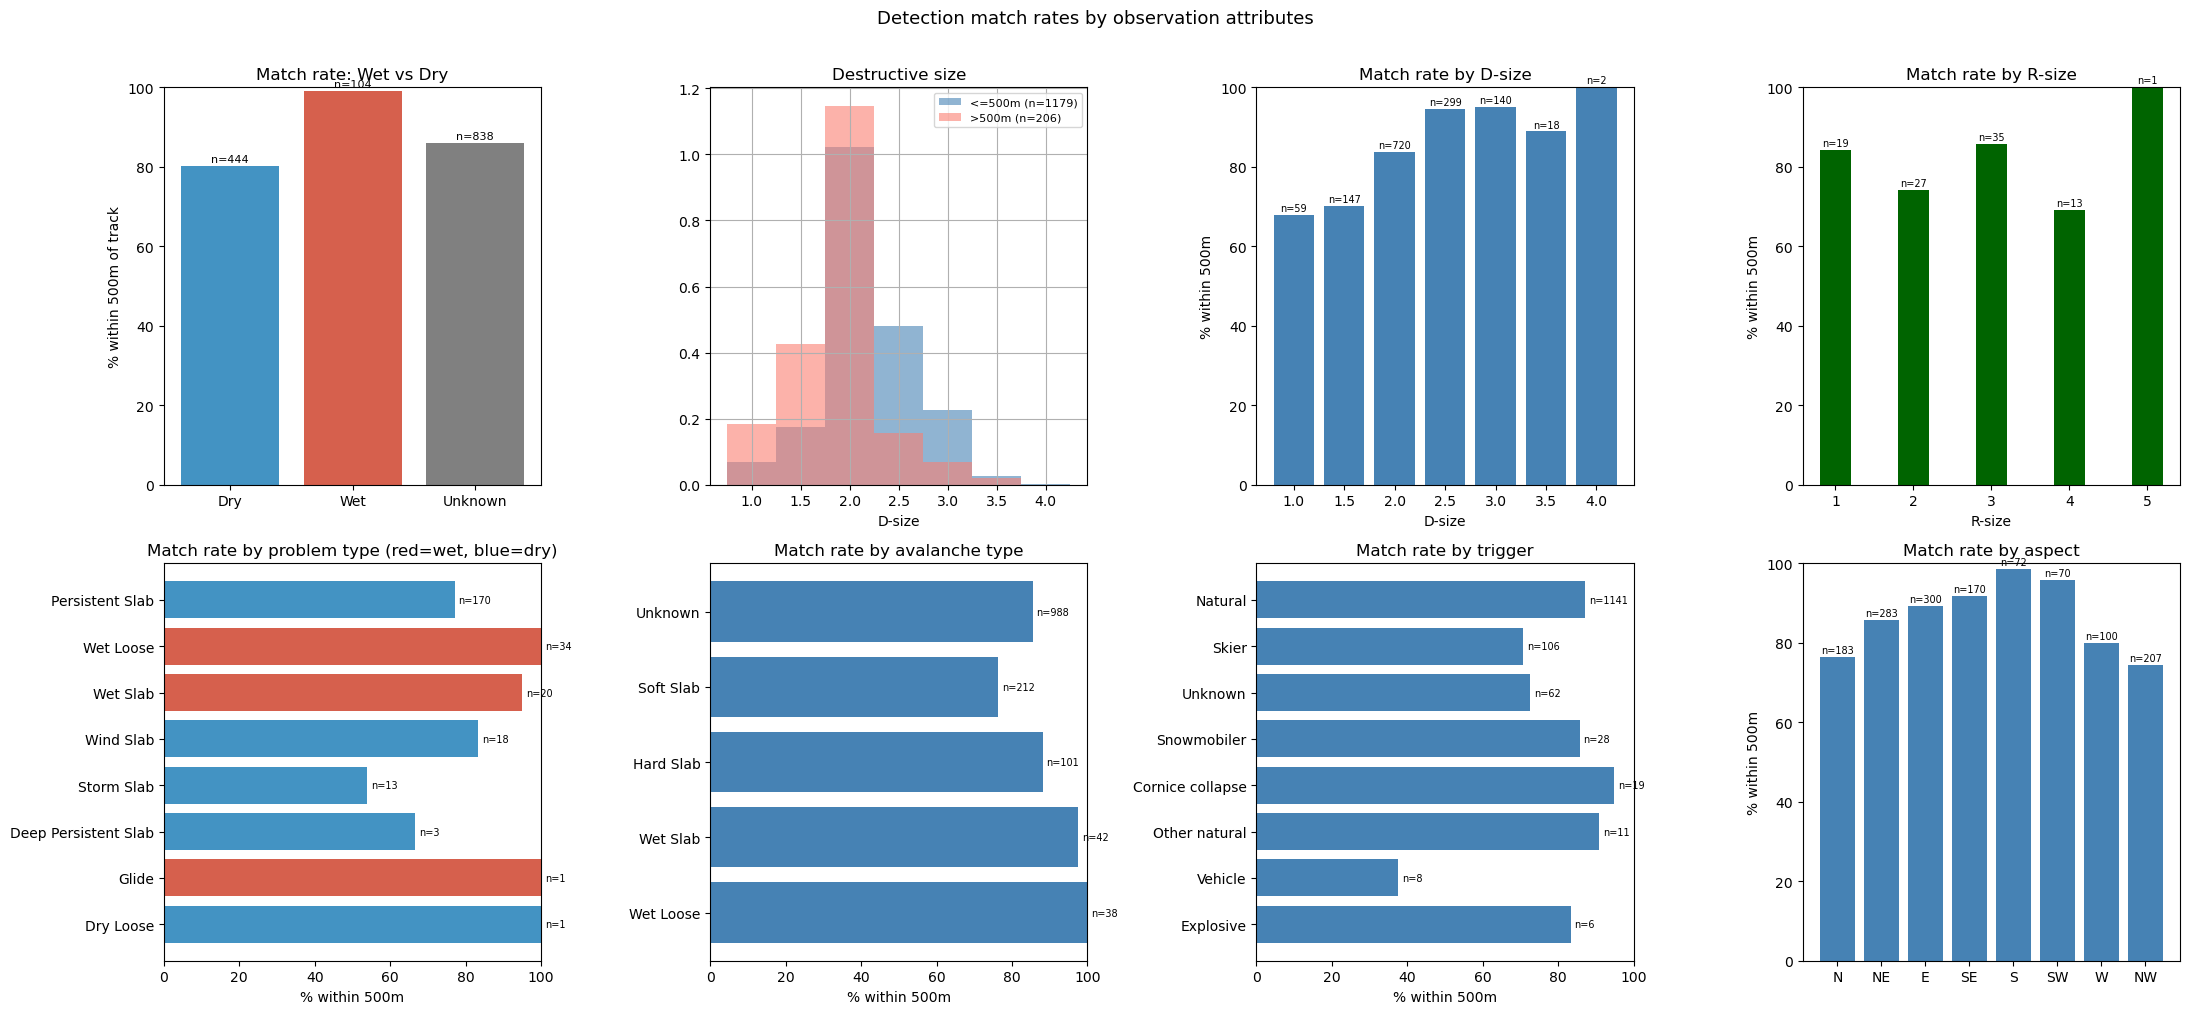

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# --- Wet vs Dry match rates ---
ax = axes[0, 0]
moisture_rate = obs.groupby('moisture')['matched_500m'].agg(['mean', 'size'])
moisture_rate = moisture_rate.reindex(['Dry', 'Wet', 'Unknown'])
bars = ax.bar(moisture_rate.index, moisture_rate['mean'] * 100,
              color=['#4393c3', '#d6604d', 'gray'])
for bar, (_, row) in zip(bars, moisture_rate.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={int(row["size"])}', ha='center', fontsize=8)
ax.set_ylabel('% within 500m of track')
ax.set_title('Match rate: Wet vs Dry')
ax.set_ylim(0, 100)

# --- D-size distribution ---
ax = axes[0, 1]
for matched, color, label in [(True, 'steelblue', '<=500m'), (False, 'salmon', '>500m')]:
    sizes = obs.loc[obs['matched_500m'] == matched, 'd_size_num'].dropna()
    if len(sizes) > 0:
        sizes.hist(bins=np.arange(0.75, 4.75, 0.5), ax=ax, alpha=0.6, color=color,
                   label=f'{label} (n={len(sizes)})', density=True)
ax.set_xlabel('D-size')
ax.set_title('Destructive size')
ax.legend(fontsize=8)

# --- D-size match rate ---
ax = axes[0, 2]
dsize_rate = obs.dropna(subset=['d_size_num']).groupby('d_size_num')['matched_500m'].agg(['mean', 'size'])
ax.bar(dsize_rate.index, dsize_rate['mean'] * 100, width=0.4, color='steelblue')
for x, row in dsize_rate.iterrows():
    ax.text(x, row['mean'] * 100 + 1, f'n={int(row["size"])}', ha='center', fontsize=7)
ax.set_xlabel('D-size')
ax.set_ylabel('% within 500m')
ax.set_title('Match rate by D-size')
ax.set_ylim(0, 100)

# --- R-size match rate ---
ax = axes[0, 3]
rsize_rate = obs.dropna(subset=['r_size_num']).groupby('r_size_num')['matched_500m'].agg(['mean', 'size'])
if len(rsize_rate) > 0:
    ax.bar(rsize_rate.index, rsize_rate['mean'] * 100, width=0.4, color='darkgreen')
    for x, row in rsize_rate.iterrows():
        ax.text(x, row['mean'] * 100 + 1, f'n={int(row["size"])}', ha='center', fontsize=7)
ax.set_xlabel('R-size')
ax.set_ylabel('% within 500m')
ax.set_title('Match rate by R-size')
ax.set_ylim(0, 100)

# --- Avalanche problem type ---
ax = axes[1, 0]
prob_rate = obs.dropna(subset=['avalanche_problem']).groupby('avalanche_problem')['matched_500m'].agg(['mean', 'size'])
prob_rate = prob_rate.sort_values('size', ascending=True)
colors_prob = ['#d6604d' if p in WET_PROBLEMS else '#4393c3' for p in prob_rate.index]
ax.barh(prob_rate.index, prob_rate['mean'] * 100, color=colors_prob)
for i, (idx, row) in enumerate(prob_rate.iterrows()):
    ax.text(row['mean'] * 100 + 1, i, f'n={int(row["size"])}', va='center', fontsize=7)
ax.set_xlabel('% within 500m')
ax.set_title('Match rate by problem type (red=wet, blue=dry)')
ax.set_xlim(0, 100)

# --- Avalanche type ---
ax = axes[1, 1]
type_rate = obs.groupby('type_label')['matched_500m'].agg(['mean', 'size'])
type_rate = type_rate[type_rate['size'] >= 5].sort_values('size', ascending=True)
ax.barh(type_rate.index, type_rate['mean'] * 100, color='steelblue')
for i, (idx, row) in enumerate(type_rate.iterrows()):
    ax.text(row['mean'] * 100 + 1, i, f'n={int(row["size"])}', va='center', fontsize=7)
ax.set_xlabel('% within 500m')
ax.set_title('Match rate by avalanche type')
ax.set_xlim(0, 100)

# --- Trigger ---
ax = axes[1, 2]
trig_rate = obs.groupby('trigger_label')['matched_500m'].agg(['mean', 'size'])
trig_rate = trig_rate[trig_rate['size'] >= 5].sort_values('size', ascending=True)
ax.barh(trig_rate.index, trig_rate['mean'] * 100, color='steelblue')
for i, (idx, row) in enumerate(trig_rate.iterrows()):
    ax.text(row['mean'] * 100 + 1, i, f'n={int(row["size"])}', va='center', fontsize=7)
ax.set_xlabel('% within 500m')
ax.set_title('Match rate by trigger')
ax.set_xlim(0, 100)

# --- Aspect ---
ax = axes[1, 3]
aspect_order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
aspect_rate = obs.groupby('aspect')['matched_500m'].agg(['mean', 'size']).reindex(aspect_order)
ax.bar(aspect_rate.index, aspect_rate['mean'] * 100, color='steelblue')
for i, (idx, row) in enumerate(aspect_rate.iterrows()):
    ax.text(i, row['mean'] * 100 + 1, f'n={int(row["size"])}', ha='center', fontsize=7)
ax.set_ylabel('% within 500m')
ax.set_title('Match rate by aspect')
ax.set_ylim(0, 100)

plt.suptitle('Detection match rates by observation attributes', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

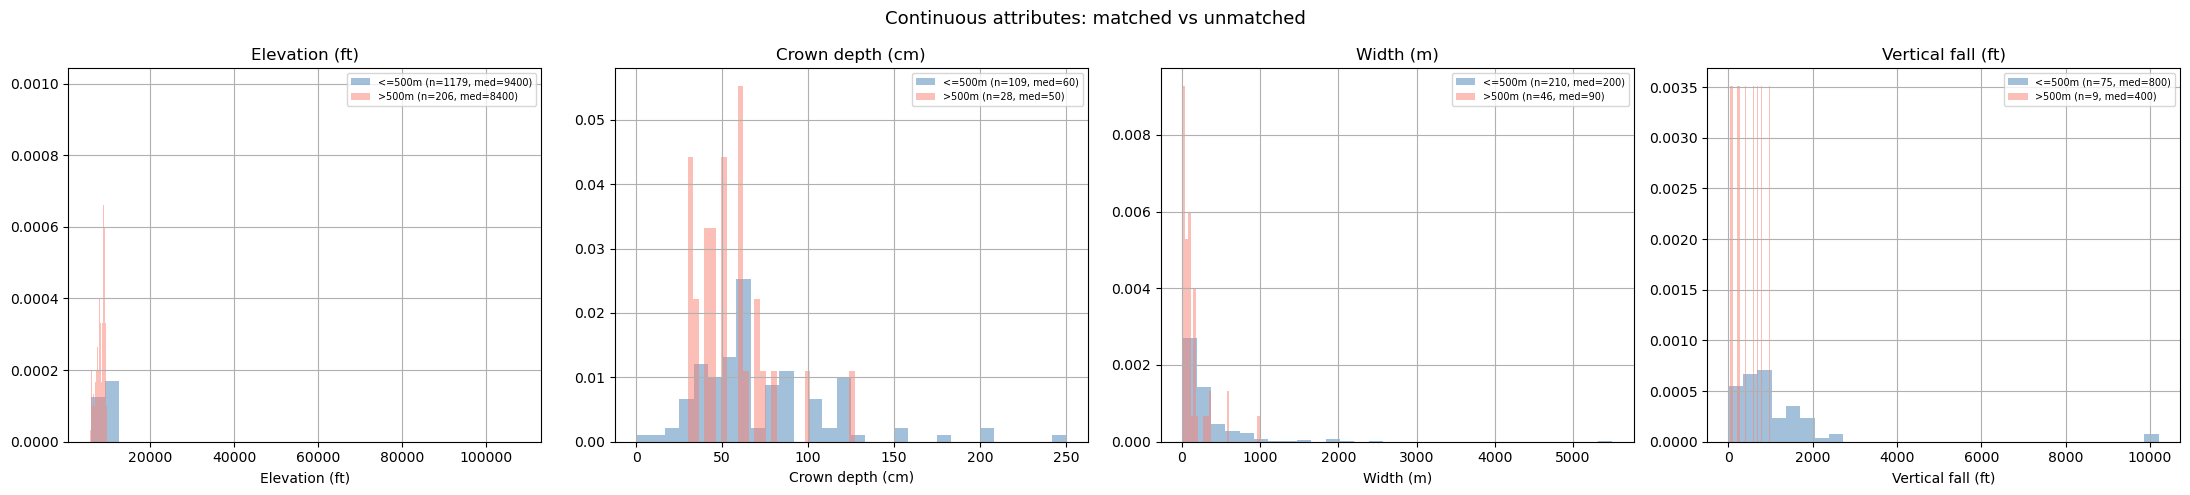

In [14]:
# --- Continuous attributes: elevation, crown depth, width, vertical fall ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

cont_attrs = [
    ('elevation_ft', 'Elevation (ft)', axes[0]),
    ('crown_depth_cm', 'Crown depth (cm)', axes[1]),
    ('width_m', 'Width (m)', axes[2]),
    ('vert_fall_ft', 'Vertical fall (ft)', axes[3]),
]

for col, xlabel, ax in cont_attrs:
    for matched, color, label in [(True, 'steelblue', '<=500m'), (False, 'salmon', '>500m')]:
        vals = obs.loc[obs['matched_500m'] == matched, col].dropna()
        if len(vals) > 0:
            vals.hist(bins=30, ax=ax, alpha=0.5, color=color,
                      label=f'{label} (n={len(vals)}, med={vals.median():.0f})', density=True)
    ax.set_xlabel(xlabel)
    ax.set_title(f'{xlabel}')
    ax.legend(fontsize=7)

plt.suptitle('Continuous attributes: matched vs unmatched', fontsize=13)
plt.tight_layout()
plt.show()

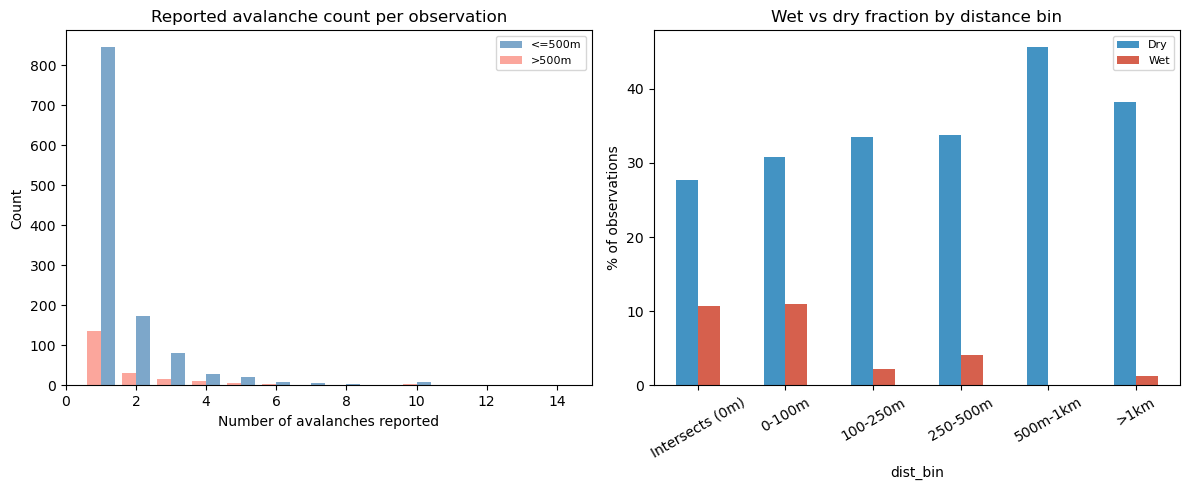

In [15]:
# --- Number of avalanches per observation event ---
obs['number_num'] = pd.to_numeric(obs['number'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for matched, color, label in [(True, 'steelblue', '<=500m'), (False, 'salmon', '>500m')]:
    vals = obs.loc[obs['matched_500m'] == matched, 'number_num'].dropna()
    counts = vals.value_counts().sort_index()
    ax.bar(counts.index + (0.2 if matched else -0.2), counts.values, width=0.4,
           color=color, alpha=0.7, label=label)
ax.set_xlabel('Number of avalanches reported')
ax.set_ylabel('Count')
ax.set_title('Reported avalanche count per observation')
ax.set_xlim(0, 15)
ax.legend(fontsize=8)

# Wet vs dry by distance bin
ax = axes[1]
moisture_by_dist = pd.crosstab(obs['dist_bin'], obs['moisture'], normalize='index') * 100
moisture_by_dist = moisture_by_dist.reindex(index=ALL_DIST_LABELS, columns=['Dry', 'Wet', 'Unknown'])
moisture_by_dist[['Dry', 'Wet']].plot.bar(stacked=False, ax=ax, color=['#4393c3', '#d6604d'])
ax.set_ylabel('% of observations')
ax.set_title('Wet vs dry fraction by distance bin')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# --- Detailed wet/dry breakdown table ---
print('Match rates by moisture and D-size:')
for m in ['Dry', 'Wet']:
    subset = obs[(obs['moisture'] == m) & obs['d_size_num'].notna()]
    if len(subset) == 0:
        continue
    print(f'\n  {m} avalanches:')
    for ds in sorted(subset['d_size_num'].unique()):
        sub_ds = subset[subset['d_size_num'] == ds]
        rate = sub_ds['matched_500m'].mean() * 100
        print(f'    D{ds}: {rate:.0f}% matched (n={len(sub_ds)})')

print('\n\nMatch rates by moisture and trigger:')
for m in ['Dry', 'Wet']:
    subset = obs[obs['moisture'] == m]
    print(f'\n  {m} avalanches:')
    trig_rates = subset.groupby('trigger_label')['matched_500m'].agg(['mean', 'size'])
    trig_rates = trig_rates[trig_rates['size'] >= 3].sort_values('size', ascending=False)
    for trig, row in trig_rates.iterrows():
        print(f'    {trig:20s}: {row["mean"]*100:.0f}% matched (n={int(row["size"])})')

Match rates by moisture and D-size:

  Dry avalanches:
    D1.0: 57% matched (n=28)
    D1.5: 71% matched (n=65)
    D2.0: 79% matched (n=233)
    D2.5: 92% matched (n=73)
    D3.0: 97% matched (n=35)
    D3.5: 78% matched (n=9)
    D4.0: 100% matched (n=1)

  Wet avalanches:
    D1.0: 100% matched (n=13)
    D1.5: 100% matched (n=9)
    D2.0: 98% matched (n=48)
    D2.5: 100% matched (n=21)
    D3.0: 100% matched (n=10)
    D3.5: 100% matched (n=2)
    D4.0: 100% matched (n=1)


Match rates by moisture and trigger:

  Dry avalanches:
    Natural             : 83% matched (n=330)
    Skier               : 69% matched (n=58)
    Unknown             : 70% matched (n=23)
    Snowmobiler         : 100% matched (n=14)
    Explosive           : 83% matched (n=6)
    Vehicle             : 40% matched (n=5)
    Other natural       : 75% matched (n=4)
    Cornice collapse    : 67% matched (n=3)

  Wet avalanches:
    Natural             : 99% matched (n=93)
    Skier               : 100% matche

## 6. Example observations — multi-track intersections

In [17]:
# Show examples of observations intersecting many tracks
multi_sorted = obs[obs['n_tracks_intersected'] > 1].sort_values(
    'n_tracks_intersected', ascending=False
).head(12)

display_cols = [
    'location_name', 'date', 'zone_short', 'n_tracks_intersected',
    'moisture', 'avalanche_type', 'd_size_num', 'r_size_num',
    'trigger_label', 'aspect', 'elevation_ft',
]
print('Top observations intersecting multiple tracks:')
multi_sorted[display_cols]

Top observations intersecting multiple tracks:


,location_name,date,zone_short,n_tracks_intersected,moisture,avalanche_type,d_size_num,r_size_num,trigger_label,aspect,elevation_ft
1173,Beaver Creek,2025-01-15,Sawtooth,8,Wet,WL,1.0,NaN,Natural,S,8500.0
939,Mill Creek - Norton Peak,2025-03-25,Galena,7,Wet,WS,2.0,NaN,Natural,E,9400.0
146,Fishhook,2023-04-06,Sawtooth,7,Wet,WL,1.0,NaN,Natural,S,9000.0
227,Baker Creek drainage,2023-03-14,Galena,6,Unknown,NaN,3.0,NaN,Natural,NW,9200.0
300,Murdock,2023-03-10,Galena,6,Unknown,NaN,3.0,NaN,Natural,S,9000.0
321,Murdock,2023-03-10,Galena,6,Unknown,NaN,3.0,NaN,Natural,S,9000.0
608,Fishhook,2024-03-08,Sawtooth,5,Wet,NaN,1.5,NaN,Natural,S,8500.0
65,Baker Divide,2021-12-26,Galena,5,Dry,SS,2.0,NaN,Natural,NE,9000.0
94,SVHS Remote Terrain - Western Smokys,2021-12-14,Sawtooth,5,Dry,SS,2.0,NaN,Natural,NE,9000.0
59,Prairie Creek,2021-12-29,Galena,4,Unknown,NaN,2.0,NaN,Natural,E,9500.0


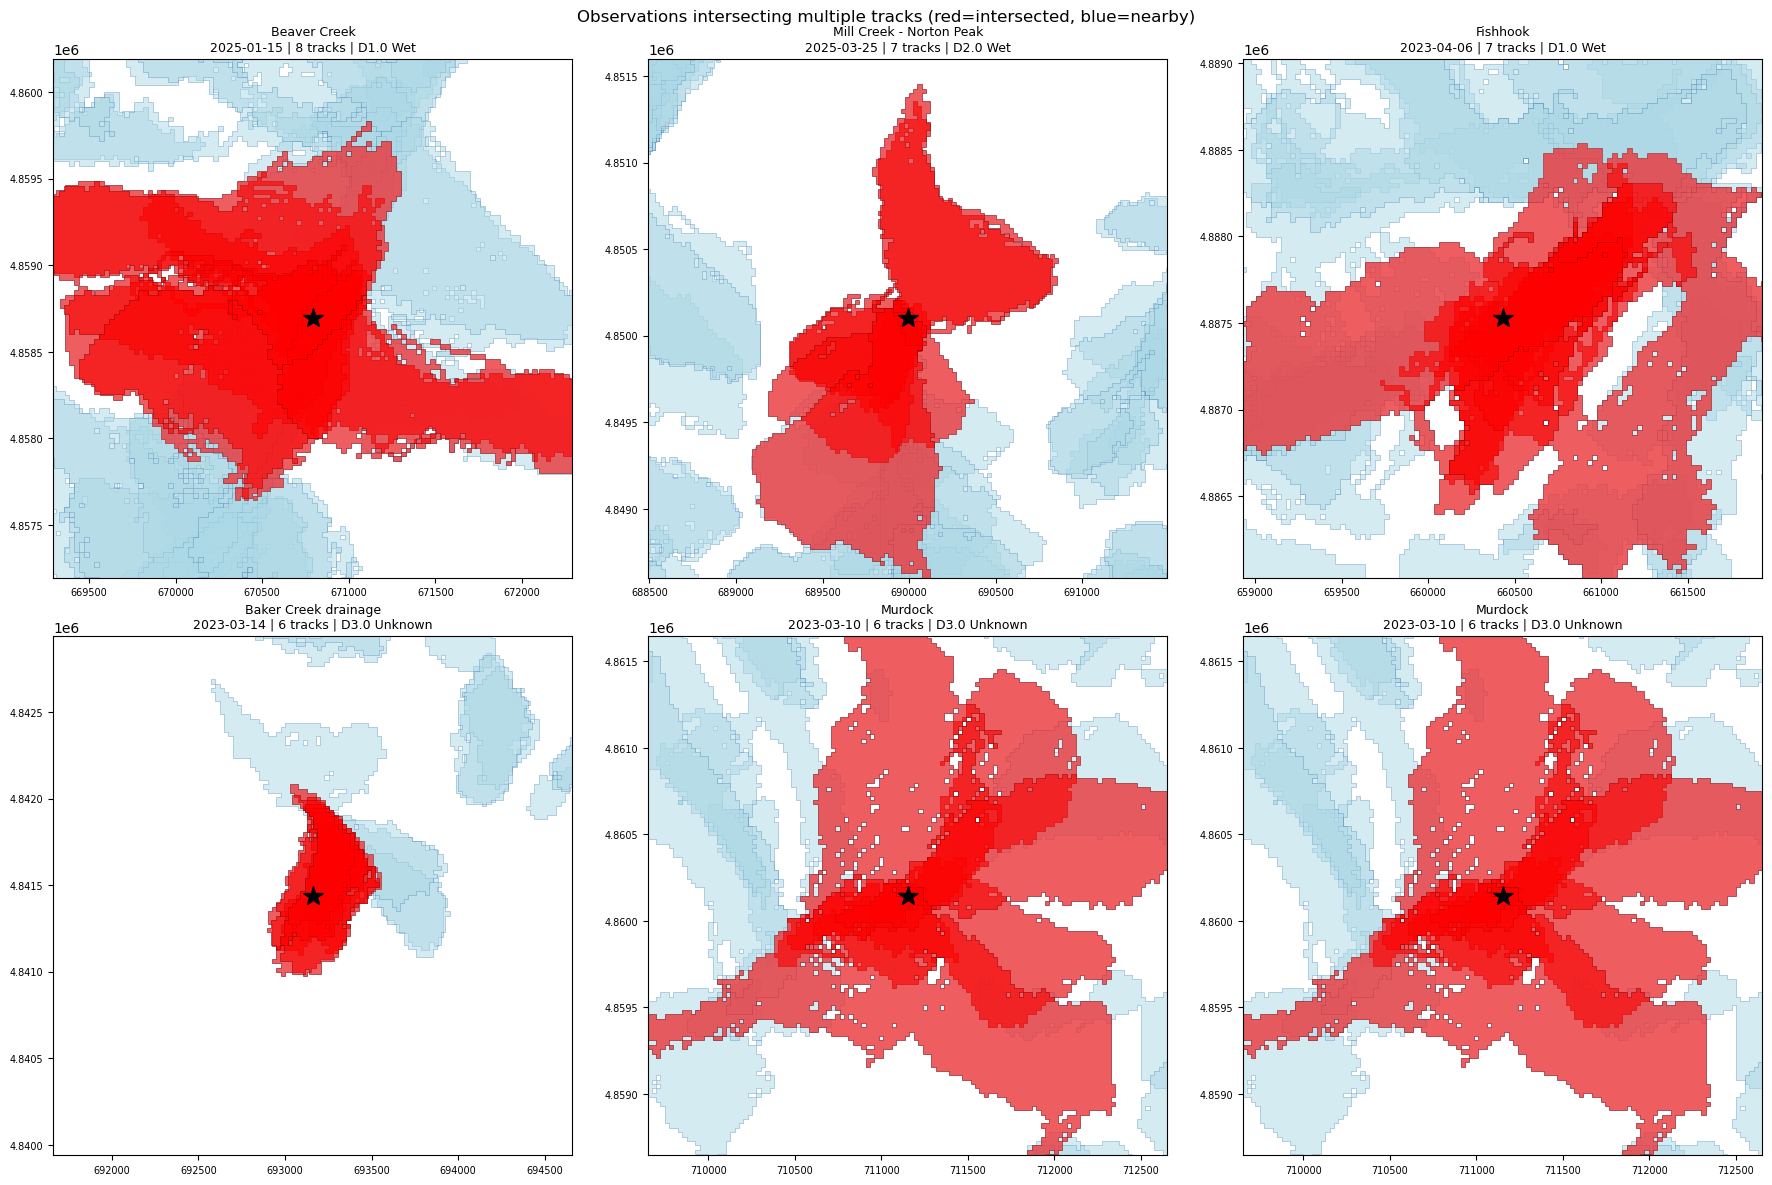

In [18]:
# Map view of multi-track observations
examples = multi_sorted.head(6)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (ax, (_, row)) in enumerate(zip(axes.flatten(), examples.iterrows())):
    pt = row.geometry
    buf = 1500  # meters around the point

    aoi = box(pt.x - buf, pt.y - buf, pt.x + buf, pt.y + buf)
    nearby_tracks = all_tracks[all_tracks.intersects(aoi)].copy()
    intersecting_tracks = all_tracks[all_tracks.intersects(pt)].copy()

    if len(nearby_tracks) > 0:
        nearby_tracks.plot(ax=ax, color='lightblue', edgecolor='steelblue', alpha=0.5, linewidth=0.5)
    if len(intersecting_tracks) > 0:
        intersecting_tracks.plot(ax=ax, color='red', edgecolor='darkred', alpha=0.6, linewidth=0.5)
    ax.plot(pt.x, pt.y, 'k*', markersize=15, zorder=10)

    ax.set_xlim(pt.x - buf, pt.x + buf)
    ax.set_ylim(pt.y - buf, pt.y + buf)
    ax.set_title(f"{row['location_name']}\n{row['date']} | {row['n_tracks_intersected']} tracks | "
                 f"D{row['d_size_num']} {row['moisture']}", fontsize=9)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)

fig.suptitle('Observations intersecting multiple tracks (red=intersected, blue=nearby)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Example observations at different distances

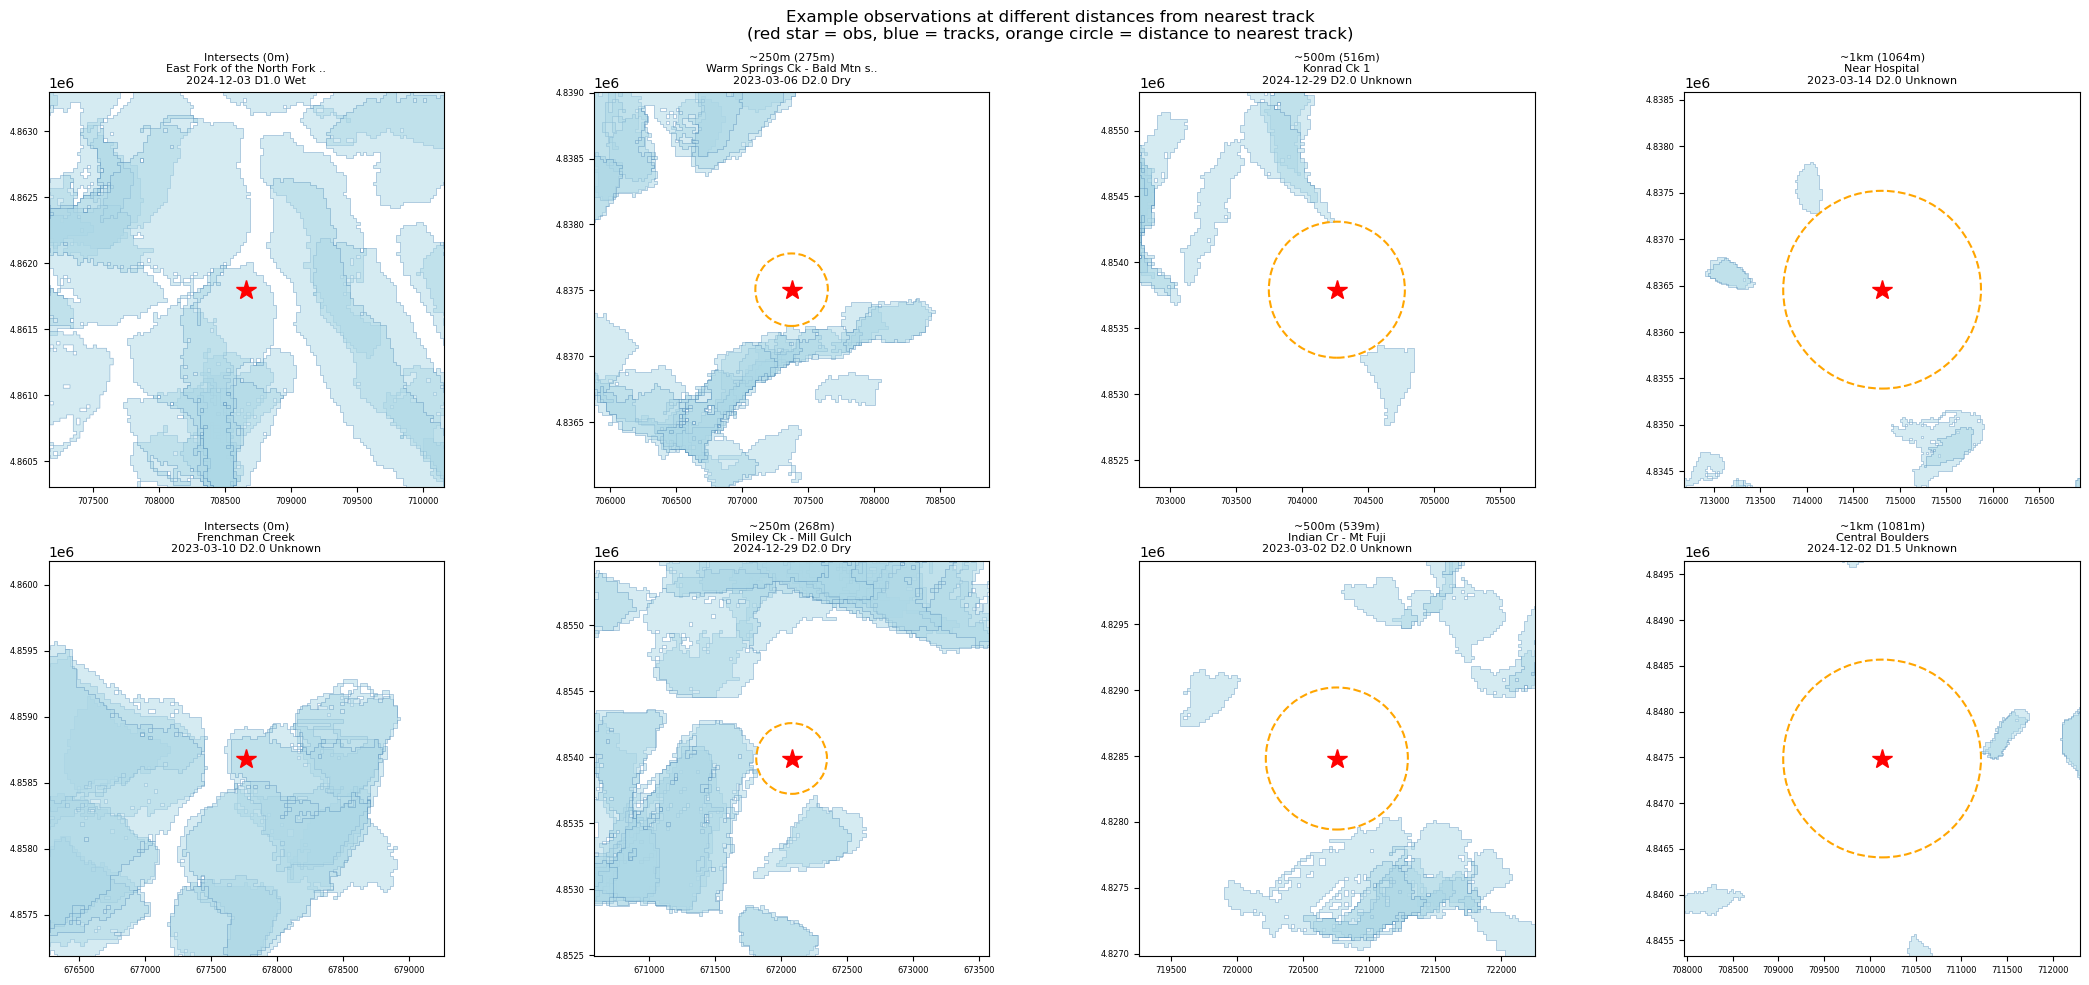

In [19]:
# Pick representative examples at each distance bin
example_bins = [
    ('Intersects', obs['dist_to_track'] == 0),
    ('~250m', (obs['dist_to_track'] > 220) & (obs['dist_to_track'] < 280)),
    ('~500m', (obs['dist_to_track'] > 450) & (obs['dist_to_track'] < 550)),
    ('~1km', (obs['dist_to_track'] > 900) & (obs['dist_to_track'] < 1100)),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for col, (label, mask) in enumerate(example_bins):
    subset = obs[mask]
    if len(subset) == 0:
        for row_ax in range(2):
            axes[row_ax, col].set_title(f'{label}: no examples')
        continue
    samples = subset.sample(n=min(2, len(subset)), random_state=42)

    for row_ax, (_, row) in enumerate(samples.iterrows()):
        ax = axes[row_ax, col]
        pt = row.geometry
        dist = row['dist_to_track']
        buf = max(1500, dist * 2)

        aoi = box(pt.x - buf, pt.y - buf, pt.x + buf, pt.y + buf)
        nearby_tracks = all_tracks[all_tracks.intersects(aoi)].copy()

        if len(nearby_tracks) > 0:
            nearby_tracks.plot(ax=ax, color='lightblue', edgecolor='steelblue', alpha=0.5, linewidth=0.5)

        # Draw distance circle
        if dist > 0:
            circle = plt.Circle((pt.x, pt.y), dist, fill=False, edgecolor='orange',
                                linestyle='--', linewidth=1.5)
            ax.add_patch(circle)

        ax.plot(pt.x, pt.y, 'r*', markersize=15, zorder=10)
        ax.set_xlim(pt.x - buf, pt.x + buf)
        ax.set_ylim(pt.y - buf, pt.y + buf)
        name = row.get('location_name', '')
        if isinstance(name, str) and len(name) > 30:
            name = name[:28] + '..'
        ax.set_title(f'{label} ({dist:.0f}m)\n{name}\n{row["date"]} D{row["d_size_num"]} {row["moisture"]}',
                     fontsize=8)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=6)

fig.suptitle('Example observations at different distances from nearest track\n'
             '(red star = obs, blue = tracks, orange circle = distance to nearest track)',
             fontsize=12)
plt.tight_layout()
plt.show()

## 8. Per-date detection rates

In [20]:
# For each sarvalanche run date, how many observations within +-6 days are spatially matched?
results = []
for _, rd_row in run_dates_df.iterrows():
    zone = rd_row['zone']
    run_date = rd_row['run_date']

    zone_obs = obs[obs['zone_name'] == zone].copy()
    time_mask = (zone_obs['obs_date'] - pd.Timestamp(run_date)).abs() <= pd.Timedelta(days=6)
    window_obs = zone_obs[time_mask]

    n_wet = (window_obs['moisture'] == 'Wet').sum()
    n_dry = (window_obs['moisture'] == 'Dry').sum()

    results.append({
        'zone': ZONE_SHORT.get(zone, zone),
        'run_date': pd.Timestamp(run_date).date(),
        'n_obs': len(window_obs),
        'n_wet': n_wet,
        'n_dry': n_dry,
        'intersects': (window_obs['dist_to_track'] == 0).sum(),
        'within_250m': (window_obs['dist_to_track'] <= 250).sum(),
        'within_500m': (window_obs['dist_to_track'] <= 500).sum(),
        'median_dsize': window_obs['d_size_num'].median(),
    })

results_df = pd.DataFrame(results)
results_df['hit_rate_500m'] = (
    results_df['within_500m'] / results_df['n_obs'].replace(0, np.nan) * 100
).round(1)

print('Detection rates per sarvalanche run (observations within +-6 days of run date):')
print(results_df.to_string(index=False))

has_obs = results_df[results_df['n_obs'] > 0]
print(f'\nOverall (runs with obs): {has_obs["within_500m"].sum()} / {has_obs["n_obs"].sum()} '
      f'({100*has_obs["within_500m"].sum()/has_obs["n_obs"].sum():.1f}%) within 500m')

Detection rates per sarvalanche run (observations within +-6 days of run date):
    zone   run_date  n_obs  n_wet  n_dry  intersects  within_250m  within_500m  median_dsize  hit_rate_500m
  Banner 2022-12-12      0      0      0           0            0            0           NaN            NaN
  Banner 2023-03-13      1      0      1           0            1            1          2.00          100.0
  Banner 2023-04-01      2      0      1           1            2            2          2.25          100.0
  Banner 2024-01-12      5      0      0           2            5            5          2.00          100.0
  Banner 2024-02-05      1      0      0           0            0            0          2.00            0.0
  Banner 2024-02-29      4      0      0           2            4            4          1.75          100.0
  Banner 2024-12-29      3      0      1           2            2            2          2.00           66.7
  Banner 2025-02-04      2      0      0           0    

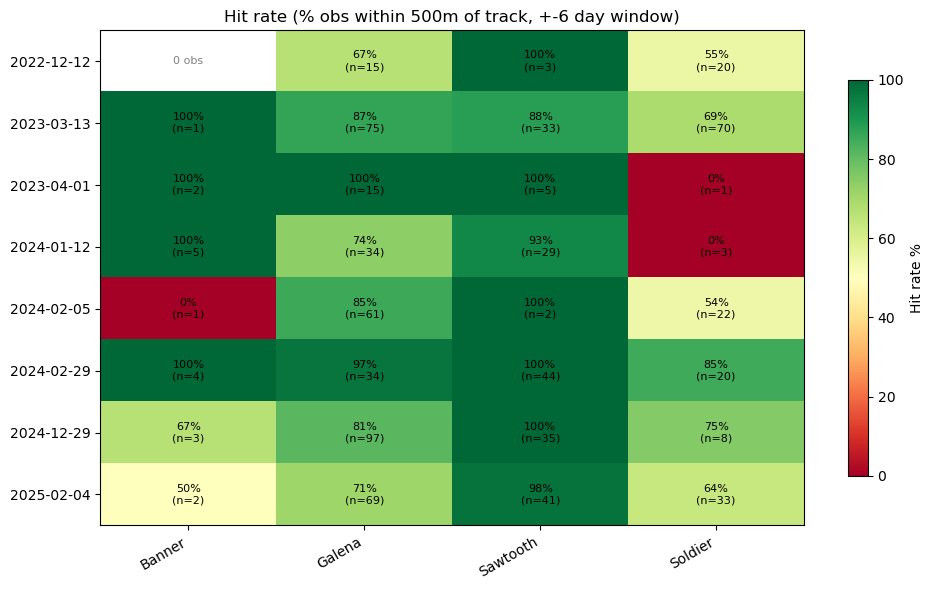

In [21]:
# Heatmap: hit rate by zone x date
pivot = results_df.pivot_table(index='run_date', columns='zone', values='hit_rate_500m')
pivot_n = results_df.pivot_table(index='run_date', columns='zone', values='n_obs')

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(d) for d in pivot.index])

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        n = pivot_n.values[i, j]
        if np.isnan(val) or np.isnan(n) or n == 0:
            ax.text(j, i, '0 obs', ha='center', va='center', fontsize=8, color='gray')
        else:
            ax.text(j, i, f'{val:.0f}%\n(n={int(n)})', ha='center', va='center', fontsize=8)

ax.set_title('Hit rate (% obs within 500m of track, +-6 day window)')
plt.colorbar(im, ax=ax, label='Hit rate %', shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Misplaced observations — terrain validation

Observer-reported locations are approximate. We can flag likely misplacements by:
1. **Slope at reported location** — avalanches need steep terrain; points on flat ground are misplaced
2. **Reported vs DEM elevation** — large discrepancies indicate the point is in the wrong spot
3. **Reported vs terrain aspect** — if the observer says "N-facing" but the DEM shows south, it's off
4. **Distance to nearest steep terrain** (>=25 deg) — how far to plausible avalanche terrain

In [22]:
# Sample terrain (DEM, slope, aspect) at each observation point from the nc files
import xarray as xr

# Load all nc files into a dict keyed by zone
nc_datasets = {}
for f in sorted(RUNS_DIR.glob('*.nc')):
    m = re.match(r'(.+)_(\d{4}-\d{2}-\d{2})\.nc$', f.name)
    if m:
        zone = m.group(1).replace('_', ' ').replace('&', '&')
        if zone not in nc_datasets:
            # Only need one per zone (terrain is static)
            nc_datasets[zone] = xr.open_dataset(f)

# Convert obs to EPSG:4326 for sampling (nc files are in lat/lon)
obs_4326 = obs.to_crs('EPSG:4326')

# Sample terrain at each observation
dem_at_obs = np.full(len(obs), np.nan)
slope_at_obs = np.full(len(obs), np.nan)
aspect_at_obs = np.full(len(obs), np.nan)

for zone, ds in nc_datasets.items():
    zone_mask = obs['zone_name'] == zone
    if not zone_mask.any():
        continue
    zone_pts = obs_4326[zone_mask]
    for idx in zone_pts.index:
        pt = zone_pts.loc[idx, 'geometry']
        try:
            dem_val = float(ds['dem'].sel(x=pt.x, y=pt.y, method='nearest').values)
            slope_val = float(ds['slope'].sel(x=pt.x, y=pt.y, method='nearest').values)
            aspect_val = float(ds['aspect'].sel(x=pt.x, y=pt.y, method='nearest').values)
            dem_at_obs[obs.index.get_loc(idx)] = dem_val
            slope_at_obs[obs.index.get_loc(idx)] = np.degrees(slope_val)
            aspect_at_obs[obs.index.get_loc(idx)] = np.degrees(aspect_val)
        except (KeyError, ValueError):
            pass

obs['dem_m'] = dem_at_obs
obs['slope_deg'] = slope_at_obs
obs['aspect_deg'] = aspect_at_obs

# Convert reported elevation from feet to meters for comparison
obs['elevation_m'] = obs['elevation_ft'] * 0.3048
obs['elev_error_m'] = obs['dem_m'] - obs['elevation_m']

# Aspect comparison: convert reported cardinal to degrees
aspect_to_deg = {'N': 0, 'NE': 45, 'E': 90, 'SE': 135, 'S': 180, 'SW': 225, 'W': 270, 'NW': 315}
obs['reported_aspect_deg'] = obs['aspect'].map(aspect_to_deg)

def angular_diff(a, b):
    """Minimum angular difference in degrees."""
    diff = np.abs(a - b) % 360
    return np.minimum(diff, 360 - diff)

obs['aspect_error_deg'] = angular_diff(obs['aspect_deg'], obs['reported_aspect_deg'])

print(f'Observations with terrain data: {obs["dem_m"].notna().sum()} / {len(obs)}')
print(f'\nSlope at observation point (degrees):')
print(obs['slope_deg'].describe().round(1).to_string())
print(f'\nElevation error (DEM - reported, meters):')
print(obs['elev_error_m'].dropna().describe().round(1).to_string())
print(f'\nAspect error (degrees):')
print(obs['aspect_error_deg'].dropna().describe().round(1).to_string())

Observations with terrain data: 1382 / 1386

Slope at observation point (degrees):
count    1382.0
mean       33.9
std         9.1
min         0.0
25%        30.2
50%        35.0
75%        39.0
max        67.0

Elevation error (DEM - reported, meters):
count     1381.0
mean       -47.0
std        804.4
min     -29617.6
25%        -37.1
50%         -8.7
75%         13.3
max        455.3

Aspect error (degrees):
count    1381.0
mean       25.4
std        25.4
min         0.0
25%         9.0
50%        19.0
75%        32.0
max       178.0


In [23]:
# Flag likely misplacements using multiple criteria
obs['on_flat'] = obs['slope_deg'] < 15  # avalanches rarely start/run on <15 deg terrain
obs['big_elev_error'] = obs['elev_error_m'].abs() > 150  # >150m elevation mismatch (~500ft)
obs['big_aspect_error'] = obs['aspect_error_deg'] > 90  # reported vs terrain aspect >90 deg off

obs['misplace_score'] = (
    obs['on_flat'].astype(int) +
    obs['big_elev_error'].fillna(False).astype(int) +
    obs['big_aspect_error'].fillna(False).astype(int)
)

print('Misplacement indicators (among obs with terrain data):')
has_terrain = obs['dem_m'].notna()
print(f'  On flat terrain (<15 deg):    {obs.loc[has_terrain, "on_flat"].sum():4d} '
      f'({100*obs.loc[has_terrain, "on_flat"].mean():.1f}%)')
print(f'  Elevation error >150m:        {obs.loc[has_terrain, "big_elev_error"].sum():4d} '
      f'({100*obs.loc[has_terrain, "big_elev_error"].mean():.1f}%)')
has_aspect = obs['aspect_error_deg'].notna()
print(f'  Aspect error >90 deg:         {obs.loc[has_aspect, "big_aspect_error"].sum():4d} '
      f'({100*obs.loc[has_aspect, "big_aspect_error"].mean():.1f}%)')
print(f'\nMisplacement score (0=OK, 3=very likely misplaced):')
print(obs.loc[has_terrain, 'misplace_score'].value_counts().sort_index().to_string())

# Match rate by misplacement score
print(f'\nMatch rate (<=500m) by misplacement score:')
for score in sorted(obs['misplace_score'].dropna().unique()):
    subset = obs[obs['misplace_score'] == score]
    rate = subset['matched_500m'].mean() * 100
    print(f'  Score {int(score)}: {rate:.1f}% matched (n={len(subset)})')

Misplacement indicators (among obs with terrain data):
  On flat terrain (<15 deg):      64 (4.6%)
  Elevation error >150m:          94 (6.8%)
  Aspect error >90 deg:           48 (3.5%)

Misplacement score (0=OK, 3=very likely misplaced):
misplace_score
0    1231
1     104
2      39
3       8

Match rate (<=500m) by misplacement score:
  Score 0: 86.2% matched (n=1235)
  Score 1: 84.6% matched (n=104)
  Score 2: 61.5% matched (n=39)
  Score 3: 50.0% matched (n=8)


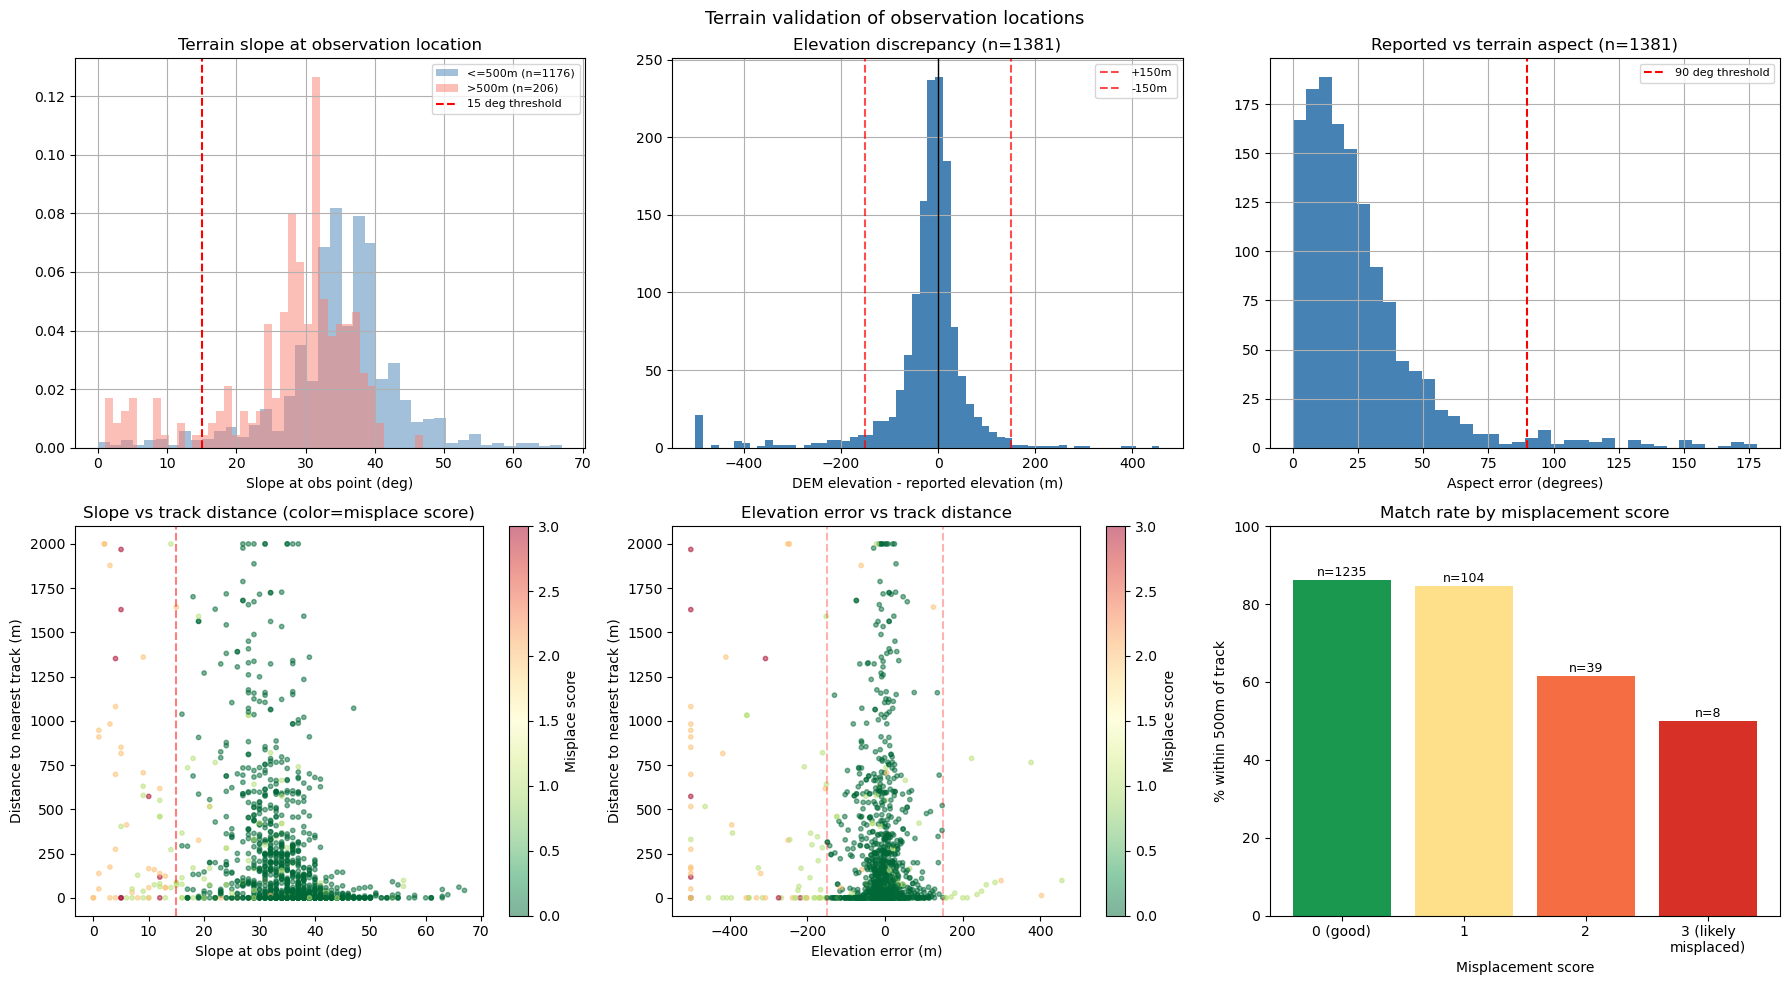

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Slope at obs point ---
ax = axes[0, 0]
for matched, color, label in [(True, 'steelblue', '<=500m'), (False, 'salmon', '>500m')]:
    vals = obs.loc[(obs['matched_500m'] == matched) & obs['slope_deg'].notna(), 'slope_deg']
    if len(vals) > 0:
        vals.hist(bins=40, ax=ax, alpha=0.5, color=color,
                  label=f'{label} (n={len(vals)})', density=True)
ax.axvline(15, color='red', linestyle='--', label='15 deg threshold')
ax.set_xlabel('Slope at obs point (deg)')
ax.set_title('Terrain slope at observation location')
ax.legend(fontsize=8)

# --- Elevation error ---
ax = axes[0, 1]
elev_err = obs['elev_error_m'].dropna()
elev_err.clip(-500, 500).hist(bins=60, ax=ax, color='steelblue', edgecolor='none')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(150, color='red', linestyle='--', alpha=0.7, label='+150m')
ax.axvline(-150, color='red', linestyle='--', alpha=0.7, label='-150m')
ax.set_xlabel('DEM elevation - reported elevation (m)')
ax.set_title(f'Elevation discrepancy (n={len(elev_err)})')
ax.legend(fontsize=8)

# --- Aspect error ---
ax = axes[0, 2]
aspect_err = obs['aspect_error_deg'].dropna()
aspect_err.hist(bins=36, ax=ax, color='steelblue', edgecolor='none')
ax.axvline(90, color='red', linestyle='--', label='90 deg threshold')
ax.set_xlabel('Aspect error (degrees)')
ax.set_title(f'Reported vs terrain aspect (n={len(aspect_err)})')
ax.legend(fontsize=8)

# --- Slope vs distance to track (scatter) ---
ax = axes[1, 0]
valid = obs[obs['slope_deg'].notna()].copy()
sc = ax.scatter(valid['slope_deg'], valid['dist_to_track'].clip(upper=2000),
                c=valid['misplace_score'], cmap='RdYlGn_r', s=10, alpha=0.5, vmin=0, vmax=3)
ax.set_xlabel('Slope at obs point (deg)')
ax.set_ylabel('Distance to nearest track (m)')
ax.set_title('Slope vs track distance (color=misplace score)')
plt.colorbar(sc, ax=ax, label='Misplace score')
ax.axvline(15, color='red', linestyle='--', alpha=0.5)

# --- Elevation error vs distance ---
ax = axes[1, 1]
valid2 = obs[obs['elev_error_m'].notna()].copy()
sc = ax.scatter(valid2['elev_error_m'].clip(-500, 500), valid2['dist_to_track'].clip(upper=2000),
                c=valid2['misplace_score'], cmap='RdYlGn_r', s=10, alpha=0.5, vmin=0, vmax=3)
ax.set_xlabel('Elevation error (m)')
ax.set_ylabel('Distance to nearest track (m)')
ax.set_title('Elevation error vs track distance')
plt.colorbar(sc, ax=ax, label='Misplace score')
ax.axvline(150, color='red', linestyle='--', alpha=0.3)
ax.axvline(-150, color='red', linestyle='--', alpha=0.3)

# --- Misplace score vs match rate ---
ax = axes[1, 2]
score_rate = obs.dropna(subset=['misplace_score']).groupby('misplace_score')['matched_500m'].agg(['mean', 'size'])
ax.bar(score_rate.index.astype(int), score_rate['mean'] * 100, color=['#1a9850', '#fee08b', '#f46d43', '#d73027'])
for x, row in score_rate.iterrows():
    ax.text(int(x), row['mean'] * 100 + 1, f'n={int(row["size"])}', ha='center', fontsize=9)
ax.set_xlabel('Misplacement score')
ax.set_ylabel('% within 500m of track')
ax.set_title('Match rate by misplacement score')
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0 (good)', '1', '2', '3 (likely\nmisplaced)'])
ax.set_ylim(0, 100)

plt.suptitle('Terrain validation of observation locations', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# Worst misplacements: score >= 2 and temporally aligned
worst = obs[(obs['misplace_score'] >= 2) & (obs['min_days_any'] <= 6)].copy()
worst = worst.sort_values('misplace_score', ascending=False)

print(f'Likely misplaced observations (score>=2, within +-6d of run): {len(worst)}')
print()
misplace_cols = [
    'location_name', 'date', 'zone_short', 'dist_to_track',
    'slope_deg', 'elev_error_m', 'aspect_error_deg', 'misplace_score',
    'd_size_num', 'aspect', 'elevation_ft',
]
worst[misplace_cols].head(20)


Likely misplaced observations (score>=2, within +-6d of run): 19



,location_name,date,zone_short,dist_to_track,slope_deg,elev_error_m,aspect_error_deg,misplace_score,d_size_num,aspect,elevation_ft
846,Owl Ck,2024-01-17,Galena,1628.874219,5.0,-785.641299,105.0,3,2.5,NE,9700.0
630,Alturas Lake Creek,2024-03-04,Sawtooth,0.000000,12.0,-546.402979,165.0,3,2.5,E,9500.0
153,Salmon River Headwaters - SW of Camas County H...,2023-04-02,Galena,30.936957,7.0,34.521709,176.0,2,3.0,NW,10100.0
1284,Central Boulders,2024-12-29,Galena,164.977996,10.0,-807.259336,13.0,2,2.0,S,10300.0
1279,Avalanche Peak,2024-12-29,Galena,1642.994502,15.0,124.441846,138.0,2,1.5,NW,9000.0
1238,White Cloud Foothills,2024-12-29,Galena,706.856757,9.0,4.416055,94.0,2,1.0,N,7300.0
1230,Banner,2024-12-30,Banner,697.698801,4.0,-550.142529,50.0,2,2.0,E,8500.0
1217,Central Boulders,2025-01-03,Galena,13.130724,32.0,402.762158,98.0,2,1.5,SE,9000.0
1207,Alturas Lake Creek,2025-01-03,Sawtooth,137.491918,12.0,-320.338184,5.0,2,2.0,E,9000.0
1041,Headwaters,2025-02-05,Sawtooth,0.000000,3.0,-331.103750,53.0,2,2.5,N,8700.0


All obs with terrain data: 1386
Well-placed obs (score<=1): 1339
Likely misplaced (score>=2): 47

Match rates (<=500m):
  All observations:     85.1%
  Well-placed only:     86.0%
  Likely misplaced:     59.6%

Distance distribution (well-placed only):
  Intersects (0m)     :  510  (38.1%)
  0-100m              :  331  (24.7%)
  100-250m            :  169  (12.6%)
  250-500m            :  142  (10.6%)
  500m-1km            :  115  (8.6%)
  >1km                :   72  (5.4%)


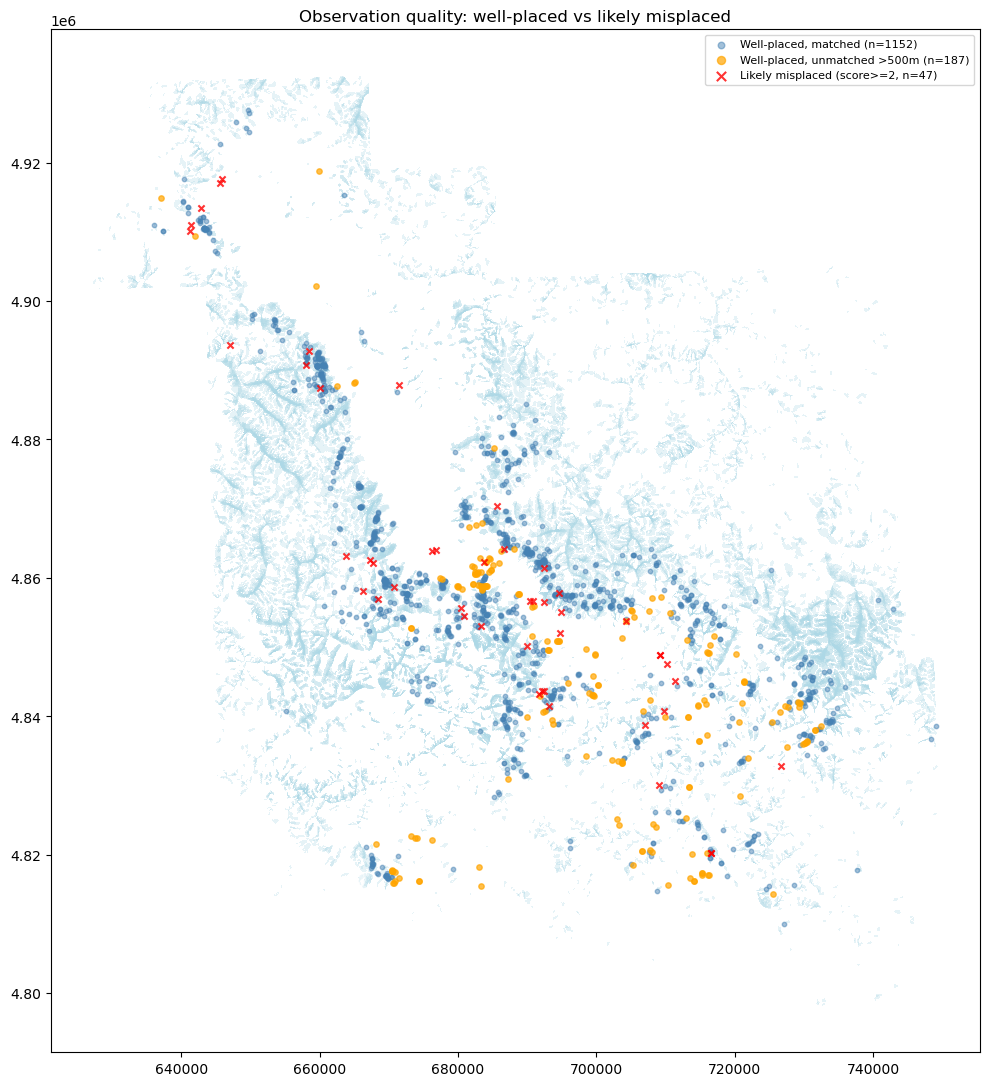

In [26]:
# Re-examine spatial match rates excluding likely misplaced observations
well_placed = obs[(obs['misplace_score'] <= 1) & obs['misplace_score'].notna()].copy()
all_with_terrain = obs[obs['misplace_score'].notna()].copy()

print(f'All obs with terrain data: {len(all_with_terrain)}')
print(f'Well-placed obs (score<=1): {len(well_placed)}')
print(f'Likely misplaced (score>=2): {len(all_with_terrain) - len(well_placed)}')

print(f'\nMatch rates (<=500m):')
print(f'  All observations:     {all_with_terrain["matched_500m"].mean()*100:.1f}%')
print(f'  Well-placed only:     {well_placed["matched_500m"].mean()*100:.1f}%')
misplaced = obs[(obs['misplace_score'] >= 2) & obs['misplace_score'].notna()]
print(f'  Likely misplaced:     {misplaced["matched_500m"].mean()*100:.1f}%')

# Adjusted distance summary for well-placed obs
print(f'\nDistance distribution (well-placed only):')
wp_dist = well_placed['dist_bin'].value_counts().reindex(ALL_DIST_LABELS, fill_value=0)
for label, count in wp_dist.items():
    print(f'  {label:20s}: {count:4d}  ({100*count/len(well_placed):.1f}%)')

# Spatial map: highlight misplaced vs well-placed
fig, ax = plt.subplots(figsize=(10, 12))
all_tracks.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.3)

well_far = well_placed[well_placed['dist_to_track'] > 500]
well_near = well_placed[well_placed['dist_to_track'] <= 500]
misplaced_pts = obs[(obs['misplace_score'] >= 2) & obs['misplace_score'].notna()]

ax.scatter(well_near.geometry.x, well_near.geometry.y, s=10, c='steelblue',
           label=f'Well-placed, matched (n={len(well_near)})', alpha=0.5, zorder=5)
ax.scatter(well_far.geometry.x, well_far.geometry.y, s=15, c='orange',
           label=f'Well-placed, unmatched >500m (n={len(well_far)})', alpha=0.7, zorder=6)
ax.scatter(misplaced_pts.geometry.x, misplaced_pts.geometry.y, s=20, c='red', marker='x',
           label=f'Likely misplaced (score>=2, n={len(misplaced_pts)})', alpha=0.8, zorder=7)

ax.set_title('Observation quality: well-placed vs likely misplaced')
ax.legend(loc='upper right', fontsize=8, markerscale=1.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 10. Observation vs track characteristics

For each observation within 500m, find all tracks within 500m and compare geometric/terrain properties of the tracks to the observer-reported attributes (D-size, width, vertical fall, elevation, aspect).

In [ ]:
# Compute geometric properties for all tracks
from shapely import minimum_rotated_rectangle
import warnings

track_props = []
for i, row in all_tracks.iterrows():
    geom = row.geometry
    area = geom.area
    perimeter = geom.length
    bounds = geom.bounds  # minx, miny, maxx, maxy
    bbox_width = bounds[2] - bounds[0]
    bbox_height = bounds[3] - bounds[1]

    # Minimum rotated rectangle for length/width
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        mrr = minimum_rotated_rectangle(geom)
    if mrr is not None and not mrr.is_empty:
        coords = list(mrr.exterior.coords)
        edges = [np.sqrt((coords[j+1][0]-coords[j][0])**2 +
                         (coords[j+1][1]-coords[j][1])**2) for j in range(4)]
        edges_sorted = sorted(edges)
        track_width = edges_sorted[0]
        track_length = edges_sorted[-1]
    else:
        track_width = min(bbox_width, bbox_height)
        track_length = max(bbox_width, bbox_height)

    track_props.append({
        'track_idx': i,
        'area_m2': area,
        'area_ha': area / 1e4,
        'perimeter_m': perimeter,
        'track_width_m': track_width,
        'track_length_m': track_length,
        'elongation': track_length / max(track_width, 1),
        'bbox_height_m': bbox_height,  # rough N-S extent (proxy for vertical in UTM)
    })

track_props_df = pd.DataFrame(track_props)
all_tracks_with_props = all_tracks.copy()
all_tracks_with_props = all_tracks_with_props.join(track_props_df.set_index('track_idx'))

print(f'Track properties computed for {len(track_props_df)} tracks')
print(f'\nTrack area (ha): median={track_props_df["area_ha"].median():.2f}, '
      f'mean={track_props_df["area_ha"].mean():.2f}, max={track_props_df["area_ha"].max():.1f}')
print(f'Track width (m): median={track_props_df["track_width_m"].median():.0f}, '
      f'mean={track_props_df["track_width_m"].mean():.0f}')
print(f'Track length (m): median={track_props_df["track_length_m"].median():.0f}, '
      f'mean={track_props_df["track_length_m"].mean():.0f}')

In [ ]:
# Sample DEM within each track to get elevation range (vertical fall proxy)
# Use the zone nc files; tracks are in UTM, DEM is in lat/lon
from pyproj import Transformer
transformer = Transformer.from_crs('EPSG:32611', 'EPSG:4326', always_xy=True)

track_elev_min = np.full(len(all_tracks), np.nan)
track_elev_max = np.full(len(all_tracks), np.nan)
track_mean_slope = np.full(len(all_tracks), np.nan)

# Process by zone to avoid reloading nc files
for zone, ds in nc_datasets.items():
    zone_mask = all_tracks_with_props['zone'] == zone
    if not zone_mask.any():
        continue

    dem = ds['dem'].values
    slope_arr = ds['slope'].values
    y_coords = ds['y'].values
    x_coords = ds['x'].values

    for idx in all_tracks_with_props[zone_mask].index:
        geom = all_tracks_with_props.loc[idx, 'geometry']
        # Get bounding box in lat/lon
        b = geom.bounds  # UTM
        lon_min, lat_min = transformer.transform(b[0], b[1])
        lon_max, lat_max = transformer.transform(b[2], b[3])

        # Find pixel indices within bounding box
        yi = np.where((y_coords >= min(lat_min, lat_max)) & (y_coords <= max(lat_min, lat_max)))[0]
        xi = np.where((x_coords >= min(lon_min, lon_max)) & (x_coords <= max(lon_min, lon_max)))[0]

        if len(yi) == 0 or len(xi) == 0:
            continue

        dem_patch = dem[yi[0]:yi[-1]+1, xi[0]:xi[-1]+1]
        slope_patch = slope_arr[yi[0]:yi[-1]+1, xi[0]:xi[-1]+1]

        valid = ~np.isnan(dem_patch)
        if valid.sum() > 0:
            track_elev_min[idx] = np.nanmin(dem_patch)
            track_elev_max[idx] = np.nanmax(dem_patch)
            track_mean_slope[idx] = np.degrees(np.nanmean(slope_patch))

all_tracks_with_props['elev_min_m'] = track_elev_min
all_tracks_with_props['elev_max_m'] = track_elev_max
all_tracks_with_props['elev_range_m'] = track_elev_max - track_elev_min
all_tracks_with_props['vert_fall_m'] = track_elev_max - track_elev_min  # proxy
all_tracks_with_props['mean_slope_deg'] = track_mean_slope

print(f'Tracks with elevation data: {(~np.isnan(track_elev_min)).sum()} / {len(all_tracks)}')
print(f'Elevation range (m): median={np.nanmedian(all_tracks_with_props["elev_range_m"]):.0f}, '
      f'mean={np.nanmean(all_tracks_with_props["elev_range_m"]):.0f}')

In [ ]:
# Match observations to nearby tracks (within 500m) and aggregate track properties
# For each obs, find all tracks within 500m and take the nearest + summary stats

nearby_obs = obs[obs['matched_500m']].copy()

# Buffer obs points by 500m and spatial join
obs_buffered = nearby_obs[['geometry']].copy()
obs_buffered['geometry'] = obs_buffered.geometry.buffer(500)
joined_nearby = gpd.sjoin(
    all_tracks_with_props, obs_buffered, how='inner', predicate='intersects'
)

# For each observation, aggregate matched track properties
obs_track_matches = []
for obs_idx in nearby_obs.index:
    matched = joined_nearby[joined_nearby['index_right'] == obs_idx]
    if len(matched) == 0:
        continue

    # Nearest track
    dists = matched.geometry.apply(lambda g: nearby_obs.loc[obs_idx, 'geometry'].distance(g))
    nearest_idx = dists.idxmin()
    nearest = matched.loc[nearest_idx]

    obs_row = nearby_obs.loc[obs_idx]
    obs_track_matches.append({
        'obs_idx': obs_idx,
        'n_tracks_500m': len(matched),
        # Observation attributes
        'obs_d_size': obs_row['d_size_num'],
        'obs_width_m': obs_row['width_m'] if not pd.isna(obs_row.get('width_m')) else np.nan,
        'obs_vert_fall_ft': obs_row['vert_fall_ft'] if not pd.isna(obs_row.get('vert_fall_ft')) else np.nan,
        'obs_vert_fall_m': obs_row['vert_fall_ft'] * 0.3048 if not pd.isna(obs_row.get('vert_fall_ft')) else np.nan,
        'obs_elevation_m': obs_row['elevation_m'],
        'obs_crown_cm': obs_row['crown_depth_cm'],
        'obs_moisture': obs_row['moisture'],
        'obs_aspect': obs_row['aspect'],
        'obs_location': obs_row['location_name'],
        'obs_date': obs_row['date'],
        'obs_zone': obs_row['zone_short'],
        # Nearest track properties
        'nearest_dist_m': dists.min(),
        'nearest_area_ha': nearest['area_ha'],
        'nearest_width_m': nearest['track_width_m'],
        'nearest_length_m': nearest['track_length_m'],
        'nearest_vert_m': nearest.get('vert_fall_m', np.nan),
        'nearest_elev_min_m': nearest.get('elev_min_m', np.nan),
        'nearest_elev_max_m': nearest.get('elev_max_m', np.nan),
        'nearest_mean_slope': nearest.get('mean_slope_deg', np.nan),
        # All tracks within 500m: summary
        'max_area_ha': matched['area_ha'].max(),
        'total_area_ha': matched['area_ha'].sum(),
        'max_vert_m': matched['vert_fall_m'].max() if 'vert_fall_m' in matched else np.nan,
        'max_length_m': matched['track_length_m'].max(),
    })

matches_df = pd.DataFrame(obs_track_matches)
print(f'Observations matched to tracks within 500m: {len(matches_df)}')
print(f'Observations with reported D-size: {matches_df["obs_d_size"].notna().sum()}')
print(f'Observations with reported width: {matches_df["obs_width_m"].notna().sum()}')
print(f'Observations with reported vert fall: {matches_df["obs_vert_fall_m"].notna().sum()}')

In [ ]:
# Track properties by observed D-size
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

has_dsize = matches_df['obs_d_size'].notna()
dsizes = sorted(matches_df.loc[has_dsize, 'obs_d_size'].unique())
colors_d = plt.cm.viridis(np.linspace(0.2, 0.9, len(dsizes)))

# --- Nearest track area by D-size ---
ax = axes[0, 0]
data_by_d = [matches_df.loc[matches_df['obs_d_size'] == d, 'nearest_area_ha'].dropna() for d in dsizes]
bp = ax.boxplot(data_by_d, labels=[f'D{d}' for d in dsizes], showfliers=False, patch_artist=True)
for patch, c in zip(bp['boxes'], colors_d):
    patch.set_facecolor(c)
ax.set_ylabel('Nearest track area (ha)')
ax.set_title('Track area by reported D-size')
ax.set_yscale('log')
# Add sample sizes
for i, d in enumerate(dsizes):
    n = len(data_by_d[i])
    ax.text(i + 1, ax.get_ylim()[1] * 0.7, f'n={n}', ha='center', fontsize=7)

# --- Nearest track length by D-size ---
ax = axes[0, 1]
data_by_d = [matches_df.loc[matches_df['obs_d_size'] == d, 'nearest_length_m'].dropna() for d in dsizes]
bp = ax.boxplot(data_by_d, labels=[f'D{d}' for d in dsizes], showfliers=False, patch_artist=True)
for patch, c in zip(bp['boxes'], colors_d):
    patch.set_facecolor(c)
ax.set_ylabel('Nearest track length (m)')
ax.set_title('Track length by reported D-size')

# --- Nearest track width by D-size ---
ax = axes[0, 2]
data_by_d = [matches_df.loc[matches_df['obs_d_size'] == d, 'nearest_width_m'].dropna() for d in dsizes]
bp = ax.boxplot(data_by_d, labels=[f'D{d}' for d in dsizes], showfliers=False, patch_artist=True)
for patch, c in zip(bp['boxes'], colors_d):
    patch.set_facecolor(c)
ax.set_ylabel('Nearest track width (m)')
ax.set_title('Track width by reported D-size')

# --- Track vertical fall by D-size ---
ax = axes[1, 0]
data_by_d = [matches_df.loc[matches_df['obs_d_size'] == d, 'nearest_vert_m'].dropna() for d in dsizes]
bp = ax.boxplot(data_by_d, labels=[f'D{d}' for d in dsizes], showfliers=False, patch_artist=True)
for patch, c in zip(bp['boxes'], colors_d):
    patch.set_facecolor(c)
ax.set_ylabel('Track elevation range (m)')
ax.set_title('Track vert fall (DEM) by reported D-size')

# --- Observed vs track width (scatter) ---
ax = axes[1, 1]
has_both_w = matches_df['obs_width_m'].notna() & matches_df['nearest_width_m'].notna()
if has_both_w.sum() > 0:
    sub = matches_df[has_both_w]
    sc = ax.scatter(sub['obs_width_m'], sub['nearest_width_m'], c=sub['obs_d_size'],
                    cmap='viridis', s=30, alpha=0.6, edgecolors='gray', linewidths=0.5)
    lim = max(sub['obs_width_m'].max(), sub['nearest_width_m'].max()) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='1:1')
    ax.set_xlabel('Reported width (m)')
    ax.set_ylabel('Nearest track width (m)')
    ax.set_title(f'Reported vs track width (n={has_both_w.sum()})')
    plt.colorbar(sc, ax=ax, label='D-size')
    ax.legend(fontsize=8)

# --- Observed vs track vertical fall (scatter) ---
ax = axes[1, 2]
has_both_v = matches_df['obs_vert_fall_m'].notna() & matches_df['nearest_vert_m'].notna()
if has_both_v.sum() > 0:
    sub = matches_df[has_both_v]
    sc = ax.scatter(sub['obs_vert_fall_m'], sub['nearest_vert_m'], c=sub['obs_d_size'],
                    cmap='viridis', s=30, alpha=0.6, edgecolors='gray', linewidths=0.5)
    lim = max(sub['obs_vert_fall_m'].max(), sub['nearest_vert_m'].max()) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='1:1')
    ax.set_xlabel('Reported vertical fall (m)')
    ax.set_ylabel('Track elevation range (m)')
    ax.set_title(f'Reported vs track vert fall (n={has_both_v.sum()})')
    plt.colorbar(sc, ax=ax, label='D-size')
    ax.legend(fontsize=8)

plt.suptitle('Track characteristics vs observed avalanche attributes', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# --- Wet vs dry: track characteristics ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, ylabel, ax in [
    ('nearest_area_ha', 'Nearest track area (ha)', axes[0]),
    ('nearest_length_m', 'Nearest track length (m)', axes[1]),
    ('nearest_vert_m', 'Track elevation range (m)', axes[2]),
]:
    for moisture, color in [('Dry', '#4393c3'), ('Wet', '#d6604d'), ('Unknown', 'gray')]:
        vals = matches_df.loc[matches_df['obs_moisture'] == moisture, col].dropna()
        if len(vals) > 5:
            vals.hist(bins=30, ax=ax, alpha=0.5, color=color,
                      label=f'{moisture} (n={len(vals)}, med={vals.median():.1f})', density=True)
    ax.set_xlabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)

plt.suptitle('Track properties by observed moisture type (matched obs within 500m)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Summary table: median track properties by D-size
print('Median track properties by reported D-size:')
summary = matches_df[matches_df['obs_d_size'].notna()].groupby('obs_d_size').agg(
    n=('obs_d_size', 'size'),
    track_area_ha=('nearest_area_ha', 'median'),
    track_length_m=('nearest_length_m', 'median'),
    track_width_m=('nearest_width_m', 'median'),
    track_vert_m=('nearest_vert_m', 'median'),
    track_slope_deg=('nearest_mean_slope', 'median'),
    n_tracks_500m=('n_tracks_500m', 'median'),
).round(1)
print(summary.to_string())

print('\n\nCorrelations (where both reported and track values exist):')
for obs_col, track_col, label in [
    ('obs_width_m', 'nearest_width_m', 'Width'),
    ('obs_vert_fall_m', 'nearest_vert_m', 'Vertical fall'),
]:
    valid = matches_df[[obs_col, track_col]].dropna()
    if len(valid) > 5:
        r = valid[obs_col].corr(valid[track_col])
        print(f'  {label}: r={r:.3f} (n={len(valid)})')

# D-size vs track area correlation
valid = matches_df[['obs_d_size', 'nearest_area_ha']].dropna()
if len(valid) > 5:
    r = valid['obs_d_size'].corr(valid['nearest_area_ha'])
    print(f'  D-size vs track area: r={r:.3f} (n={len(valid)})')
    r_log = valid['obs_d_size'].corr(np.log10(valid['nearest_area_ha'].clip(lower=0.01)))
    print(f'  D-size vs log(track area): r={r_log:.3f}')

## 11. Unmatched observations and false negatives

In [28]:
# Attribute comparison: unmatched temporal-aligned vs matched
temporally_aligned = obs[obs['min_days_any'] <= 6].copy()
temporally_aligned['spatial_match'] = np.where(
    temporally_aligned['dist_to_track'] <= 500, 'Detected (<=500m)',
    np.where(temporally_aligned['dist_to_track'] <= 1000, 'Nearby (500m-1km)', 'Missed (>1km)')
)

print(f'Temporally aligned observations (+-6d of a run): {len(temporally_aligned)}')
print(f'\nSpatial match breakdown:')
print(temporally_aligned['spatial_match'].value_counts().to_string())

print(f'\nAttribute comparison (temporally aligned only):')
for attr in ['moisture', 'type_label', 'trigger_label']:
    print(f'\n  {attr}:')
    ct = pd.crosstab(temporally_aligned[attr], temporally_aligned['spatial_match'], normalize='columns')
    print(ct.round(3).to_string())

Temporally aligned observations (+-6d of a run): 791

Spatial match breakdown:
spatial_match
Detected (<=500m)    647
Nearby (500m-1km)     88
Missed (>1km)         56

Attribute comparison (temporally aligned only):

  moisture:
spatial_match  Detected (<=500m)  Missed (>1km)  Nearby (500m-1km)
moisture                                                          
Dry                        0.255          0.375              0.364
Unknown                    0.737          0.625              0.636
Wet                        0.008          0.000              0.000

  type_label:
spatial_match  Detected (<=500m)  Missed (>1km)  Nearby (500m-1km)
type_label                                                        
Hard Slab                  0.062          0.054              0.045
Roof                       0.002          0.000              0.000
Soft Slab                  0.094          0.232              0.170
Unknown                    0.838          0.714              0.784
Wet Loose         

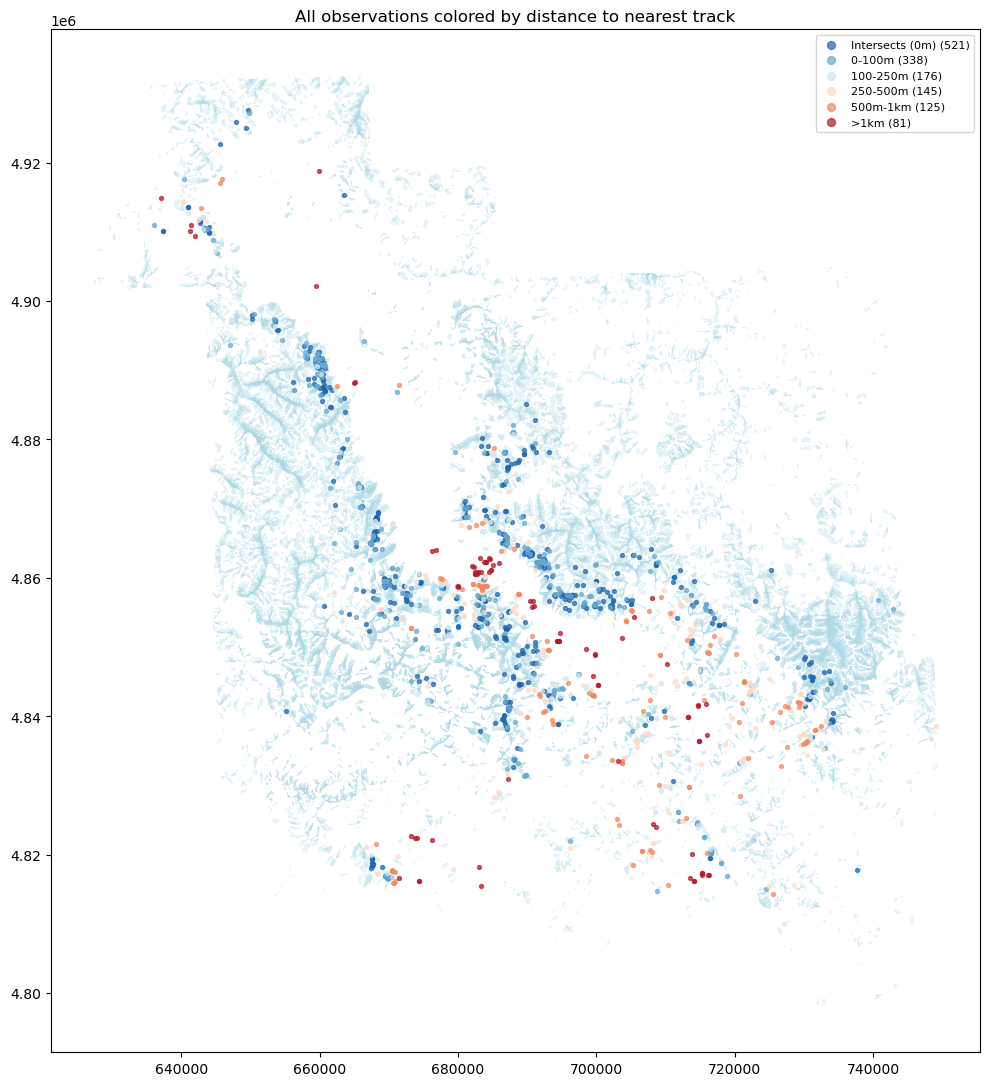

In [29]:
# Spatial view of all observations colored by distance bin
fig, ax = plt.subplots(figsize=(10, 12))

all_tracks.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.3)

cmap = {'Intersects (0m)': '#2166ac', '0-100m': '#67a9cf', '100-250m': '#d1e5f0',
        '250-500m': '#fddbc7', '500m-1km': '#ef8a62', '>1km': '#b2182b'}
for label in ALL_DIST_LABELS:
    subset = obs[obs['dist_bin'] == label]
    if len(subset) > 0:
        ax.scatter(subset.geometry.x, subset.geometry.y, s=8, c=cmap[label],
                   label=f'{label} ({len(subset)})', alpha=0.7, zorder=5)

ax.set_title('All observations colored by distance to nearest track')
ax.legend(loc='upper right', fontsize=8, markerscale=2)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 12. Summary

In [30]:
print('=' * 70)
print('SUMMARY: SNFAC Observations vs Sarvalanche Tracks')
print('=' * 70)

print(f'\nData:')
print(f'  Observations: {len(obs)}')
print(f'  Detected tracks: {len(all_tracks)} across 4 zones')
print(f'  Run dates: {len(unique_run_dates)}')

print(f'\nSpatial matching:')
for label in ALL_DIST_LABELS:
    n = (obs['dist_bin'] == label).sum()
    print(f'  {label:20s}: {n:4d} ({100*n/len(obs):.1f}%)')
cum_500 = (obs['dist_to_track'] <= 500).sum()
print(f'  {"Cumulative <=500m":20s}: {cum_500:4d} ({100*cum_500/len(obs):.1f}%)')

print(f'\nMulti-track intersections:')
print(f'  Obs intersecting 1 track:  {(obs["n_tracks_intersected"] == 1).sum()}')
print(f'  Obs intersecting 2+ tracks: {(obs["n_tracks_intersected"] > 1).sum()}')

print(f'\nTemporal matching (obs within 500m):')
for window in [3, 6, 12, 18]:
    n = ((obs['dist_to_track'] <= 500) & (obs['min_days_any'] <= window)).sum()
    print(f'  +-{window:2d} days: {n:4d} / {cum_500} ({100*n/cum_500:.1f}%)')

print(f'\nWet vs Dry detection (<=500m match rate):')
for m in ['Dry', 'Wet', 'Unknown']:
    subset = obs[obs['moisture'] == m]
    if len(subset) > 0:
        rate = subset['matched_500m'].mean() * 100
        print(f'  {m:8s}: {rate:.1f}% (n={len(subset)})')

print(f'\nD-size detection (<=500m match rate):')
for ds in sorted(obs['d_size_num'].dropna().unique()):
    subset = obs[obs['d_size_num'] == ds]
    rate = subset['matched_500m'].mean() * 100
    print(f'  D{ds}: {rate:.1f}% (n={len(subset)})')

print(f'\nSpatial + temporal combined (% of ALL {len(obs)} obs):')
for dt, tw in [(0, 6), (250, 6), (500, 6), (500, 12)]:
    n = ((obs['dist_to_track'] <= dt) & (obs['min_days_any'] <= tw)).sum()
    print(f'  <={dt}m AND +-{tw}d: {n:4d} ({100*n/len(obs):.1f}%)')

print(f'\nPotential false negatives (>1km, within +-6d of run): '
      f'{((obs["dist_to_track"] > 1000) & (obs["min_days_any"] <= 6)).sum()}')
print(f'Observations in zones without tracks (Challis): '
      f'{(obs["zone_name"] == "Challis/Lost River/Lemhi").sum()}')

SUMMARY: SNFAC Observations vs Sarvalanche Tracks

Data:
  Observations: 1386
  Detected tracks: 11891 across 4 zones
  Run dates: 8

Spatial matching:
  Intersects (0m)     :  521 (37.6%)
  0-100m              :  338 (24.4%)
  100-250m            :  176 (12.7%)
  250-500m            :  145 (10.5%)
  500m-1km            :  125 (9.0%)
  >1km                :   81 (5.8%)
  Cumulative <=500m   : 1180 (85.1%)

Multi-track intersections:
  Obs intersecting 1 track:  300
  Obs intersecting 2+ tracks: 221

Temporal matching (obs within 500m):
  +- 3 days:  542 / 1180 (45.9%)
  +- 6 days:  647 / 1180 (54.8%)
  +-12 days:  827 / 1180 (70.1%)
  +-18 days:  903 / 1180 (76.5%)

Wet vs Dry detection (<=500m match rate):
  Dry     : 80.2% (n=444)
  Wet     : 99.0% (n=104)
  Unknown : 86.0% (n=838)

D-size detection (<=500m match rate):
  D1.0: 67.8% (n=59)
  D1.5: 70.1% (n=147)
  D2.0: 83.6% (n=720)
  D2.5: 94.6% (n=299)
  D3.0: 95.0% (n=140)
  D3.5: 88.9% (n=18)
  D4.0: 100.0% (n=2)

Spatial + temp